<a href="https://colab.research.google.com/github/SiddhantMS/EDA/blob/main/EDA_Project_modified.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [41]:
import pandas as pd
import numpy as np
from pathlib import Path
import os
import matplotlib.pyplot as plt
import seaborn as sns
import textwrap
# Import gaussian_kde from scipy
# gaussian_kde is used to estimate smooth density curves for distribution overlap calculation

from scipy.stats import gaussian_kde
from scipy.stats import pearsonr
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.stats.stattools import durbin_watson, jarque_bera
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

from sklearn.linear_model import Ridge, Lasso, ElasticNet
from sklearn.metrics import mean_squared_error, r2_score


In [42]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [43]:
files = {
    "loans": "/content/drive/MyDrive/EDA_exam/loans_master.csv",
    "collateral": "/content/drive/MyDrive/EDA_exam/collateral_assets.csv",
    "enquiry": "/content/drive/MyDrive/EDA_exam/loan_enquiry_bureau.csv",
    "customer": "/content/drive/MyDrive/EDA_exam/customer_bureau.csv",
    "performance": "/content/drive/MyDrive/EDA_exam/loan_performance.csv",
    "branch": "/content/drive/MyDrive/EDA_exam/branch_region_economy.csv",
    "credit_card": "/content/drive/MyDrive/EDA_exam/credit_card_behavior.csv",
    "emi": "/content/drive/MyDrive/EDA_exam/monthly_emi_track.csv",
    "payment": "/content/drive/MyDrive/EDA_exam/payment_history.csv"
}

In [44]:
def memory_usage_mb(df):
    return df.memory_usage(deep=True).sum() / (1024 ** 2)

In [45]:
def downcast_dataframe(df):
    df = df.copy()

    for col in df.select_dtypes(include=["int64", "int32"]).columns:
        df[col] = pd.to_numeric(df[col], downcast="integer")

    for col in df.select_dtypes(include=["float64", "float32"]).columns:
        df[col] = pd.to_numeric(df[col], downcast="float")

    for col in df.select_dtypes(include=["object"]).columns:
        unique_ratio = df[col].nunique(dropna=False) / len(df)

        # Convert low-cardinality text columns to category
        # Avoid converting ID columns
        if unique_ratio < 0.5 and not col.lower().endswith("_id"):
            df[col] = df[col].astype("category")

    return df

In [46]:
import pandas as pd

datasets = {}

for tbl_name, file in files.items():
    print(f"Loading: {file}")

    try:
        datasets[tbl_name] = pd.read_csv(
            file,
            engine="python",      # more tolerant parser
            on_bad_lines="skip"   # skip malformed rows
        )

        print(tbl_name, datasets[tbl_name].shape)

    except Exception as e:
        print(f"Error loading {file}: {e}")

Loading: /content/drive/MyDrive/EDA_exam/loans_master.csv
loans (266503, 27)
Loading: /content/drive/MyDrive/EDA_exam/collateral_assets.csv
collateral (163630, 20)
Loading: /content/drive/MyDrive/EDA_exam/loan_enquiry_bureau.csv
enquiry (1151609, 24)
Loading: /content/drive/MyDrive/EDA_exam/customer_bureau.csv
customer (84049, 30)
Loading: /content/drive/MyDrive/EDA_exam/loan_performance.csv
performance (1984234, 12)
Loading: /content/drive/MyDrive/EDA_exam/branch_region_economy.csv
branch (133961, 19)
Loading: /content/drive/MyDrive/EDA_exam/credit_card_behavior.csv
credit_card (169519, 17)
Loading: /content/drive/MyDrive/EDA_exam/monthly_emi_track.csv
emi (1204725, 23)
Loading: /content/drive/MyDrive/EDA_exam/payment_history.csv
payment (1520341, 18)


In [47]:
mem_pre = {}

for tbl_name, df in datasets.items():
    mem_pre[tbl_name] = memory_usage_mb(df)

mem_pre_df = pd.DataFrame.from_dict(
    mem_pre,
    orient="index",
    columns=["Memory Before Downcasting MB"]
)

mem_pre_df

,Memory Before Downcasting MB
loans,208.500599
collateral,69.078404
enquiry,638.699125
customer,42.617514
performance,553.893745
branch,44.484205
credit_card,49.748982
emi,535.064358
payment,284.182515


In [48]:
lean_datasets = {}

for tbl_name, df in datasets.items():
    lean_datasets[tbl_name] = downcast_dataframe(df)

datasets = lean_datasets

In [49]:
mem_post = {}

for tbl_name, df in datasets.items():
    mem_post[tbl_name] = memory_usage_mb(df)

mem_summary = pd.DataFrame({
    "Memory Before MB": mem_pre,
    "Memory After MB": mem_post
})

mem_summary["Memory Saved MB"] = mem_summary["Memory Before MB"] - mem_summary["Memory After MB"]
mem_summary["Memory Saved %"] = (
    mem_summary["Memory Saved MB"] / mem_summary["Memory Before MB"]
) * 100

mem_summary

,Memory Before MB,Memory After MB,Memory Saved MB,Memory Saved %
loans,208.500599,31.791456,176.709143,84.752343
collateral,69.078404,19.366229,49.712175,71.964858
enquiry,638.699125,118.628802,520.070323,81.426497
customer,42.617514,18.236975,24.380539,57.207793
performance,553.893745,193.017417,360.876328,65.152627
branch,44.484205,21.463514,23.020691,51.750258
credit_card,49.748982,18.108252,31.640731,63.600760
emi,535.064358,186.139452,348.924906,65.211764
payment,284.182515,249.384671,34.797844,12.244893


# Q1 b

In [50]:
for tbl_name, df in datasets.items():
    print(tbl_name, "loan_id" in df.columns)

loans True
collateral True
enquiry True
customer True
performance True
branch True
credit_card True
emi True
payment True


In [51]:
EXPECTED_ROWS = 2_000_000

In [52]:
merged_df = datasets["loans"].copy()

initial_rows = datasets["loans"].shape[0]

assert merged_df.shape[0] == initial_rows, \
    "Row count mismatch"

In [53]:
import pandas as pd

# Start with loans table
merged_df = datasets["loans"].copy()

EXPECTED_ROWS = merged_df.shape[0]

print("Initial rows:", EXPECTED_ROWS)

join_sequence = [
    "collateral",
    "enquiry",
    "customer",
    "performance",
    "branch",
    "credit_card",
    "emi",
    "payment"
]

orphan_log = []

anchor_loan_ids = set(merged_df["loan_id"])

for tbl_name in join_sequence:

    right_table = datasets[tbl_name]

    print("\n" + "=" * 50)
    print(f"Merging: {tbl_name}")

    # Orphan records
    orphan_count = right_table.loc[
        ~right_table["loan_id"].isin(anchor_loan_ids),
        "loan_id"
    ].nunique()

    # Duplicate key check
    dup_count = right_table["loan_id"].duplicated().sum()

    print(f"Orphan loan_ids: {orphan_count}")
    print(f"Duplicate loan_ids: {dup_count}")

    before_rows = merged_df.shape[0]

    merged_df = merged_df.merge(
        right_table,
        on="loan_id",
        how="left",
        suffixes=("", f"_{tbl_name}")
    )

    after_rows = merged_df.shape[0]

    print(f"Rows before merge : {before_rows}")
    print(f"Rows after merge  : {after_rows}")

    if after_rows != EXPECTED_ROWS:
        print(f"WARNING: Row count changed after merging {tbl_name}")
        print(f"Expected: {EXPECTED_ROWS}")
        print(f"Actual  : {after_rows}")

        # Show duplicated loan_ids in right table
        if dup_count > 0:
            print("\nTop duplicated loan_ids:")
            print(
                right_table["loan_id"]
                .value_counts()
                .head(10)
            )

        break

    orphan_log.append({
        "Table": tbl_name,
        "Orphan loan_id count": orphan_count,
        "Duplicate loan_id count": dup_count,
        "Rows after merge": after_rows
    })

# Summary report
orphan_log_df = pd.DataFrame(orphan_log)

print("\nMerge Summary")
print(orphan_log_df)

print("\nFinal merged shape:")
print(merged_df.shape)

Initial rows: 266503

Merging: collateral
Orphan loan_ids: 1
Duplicate loan_ids: 0
Rows before merge : 266503
Rows after merge  : 266503

Merging: enquiry
Orphan loan_ids: 893511
Duplicate loan_ids: 0
Rows before merge : 266503
Rows after merge  : 266503

Merging: customer
Orphan loan_ids: 0
Duplicate loan_ids: 0
Rows before merge : 266503
Rows after merge  : 266503

Merging: performance
Orphan loan_ids: 1733496
Duplicate loan_ids: 0
Rows before merge : 266503
Rows after merge  : 266503

Merging: branch
Orphan loan_ids: 0
Duplicate loan_ids: 0
Rows before merge : 266503
Rows after merge  : 266503

Merging: credit_card
Orphan loan_ids: 0
Duplicate loan_ids: 0
Rows before merge : 266503
Rows after merge  : 266503

Merging: emi
Orphan loan_ids: 938222
Duplicate loan_ids: 0
Rows before merge : 266503
Rows after merge  : 266503

Merging: payment
Orphan loan_ids: 1264861
Duplicate loan_ids: 0
Rows before merge : 266503
Rows after merge  : 266503

Merge Summary
         Table  Orphan loan_id 

# Q1 c

In [54]:
merged_df.shape

(266503, 182)

In [55]:
merged_df.columns.tolist()

['loan_id',
 'issue_date',
 'issue_year',
 'issue_month',
 'loan_amnt_inr',
 'funded_amnt_inr',
 'loan_term_months',
 'int_rate_pct',
 'installment_inr',
 'annual_installment_inr',
 'grade',
 'sub_grade',
 'loan_purpose',
 'state_code',
 'region',
 'urban_index',
 'application_type',
 'pymnt_plan',
 'hardship_flag',
 'initial_list_status',
 'disbursement_method',
 'verification_status',
 'rbi_repo_rate_pct',
 'gdp_growth_pct',
 'cpi_inflation_pct',
 'rate_spread_pct',
 'real_interest_rate_pct',
 'has_collateral',
 'collateral_type',
 'collateral_value_inr',
 'ltv_ratio_pct',
 'loan_secured_flag',
 'property_type',
 'property_age_years',
 'property_area_sqft',
 'property_city_tier',
 'vehicle_type',
 'vehicle_age_years',
 'insurance_flag',
 'valuation_date',
 'valuation_agency',
 'charge_type',
 'collateral_score',
 'prop_value_inr',
 'vehicle_value_inr',
 'business_asset_val_inr',
 'num_enquiries_30d',
 'num_enquiries_90d',
 'num_enquiries_6m',
 'num_enquiries_12m',
 'num_enquiries_24m

In [56]:
dq_issues = []

def add_issue(issue_name, column, mask, reason, strategy):
    count = mask.sum()

    dq_issues.append({
        "Issue": issue_name,
        "Column": column,
        "Dirty Count": count,
        "Reason Invalid": reason,
        "Imputation Strategy": strategy
    })

    return mask

In [57]:
dq_masks = []

# 1. Negative or zero loan amount
if "loan_amnt" in merged_df.columns:
    mask = merged_df["loan_amnt"] <= 0
    dq_masks.append(add_issue(
        "Invalid loan amount",
        "loan_amnt",
        mask,
        "Loan amount cannot be zero or negative.",
        "Replace invalid values with median loan amount."
    ))

# 2. Negative annual income
if "annual_inc" in merged_df.columns:
    mask = merged_df["annual_inc"] <= 0
    dq_masks.append(add_issue(
        "Invalid annual income",
        "annual_inc",
        mask,
        "Annual income cannot be zero or negative.",
        "Replace invalid values with median annual income."
    ))

# 3. Interest rate outside 0 to 100
if "int_rate" in merged_df.columns:
    mask = (merged_df["int_rate"] < 0) | (merged_df["int_rate"] > 100)
    dq_masks.append(add_issue(
        "Invalid interest rate",
        "int_rate",
        mask,
        "Interest rate percentage must lie between 0 and 100.",
        "Replace with median interest rate grouped by grade if available."
    ))

# 4. Invalid DTI
if "dti" in merged_df.columns:
    mask = merged_df["dti"] < 0
    dq_masks.append(add_issue(
        "Invalid debt-to-income ratio",
        "dti",
        mask,
        "DTI cannot be negative.",
        "Replace invalid values with median DTI."
    ))

# 5. Invalid employment length
if "emp_length_years" in merged_df.columns:
    mask = (merged_df["emp_length_years"] < 0) | (merged_df["emp_length_years"] > 60)
    dq_masks.append(add_issue(
        "Invalid employment length",
        "emp_length_years",
        mask,
        "Employment length cannot be negative or unrealistically high.",
        "Replace with median employment length."
    ))

# 6. Invalid mortgage account count
if "mort_acc" in merged_df.columns:
    mask = merged_df["mort_acc"] < 0
    dq_masks.append(add_issue(
        "Invalid mortgage account count",
        "mort_acc",
        mask,
        "Number of mortgage accounts cannot be negative.",
        "Replace with median mortgage account count."
    ))

# 7. Invalid installment utilization percentage
if "il_util_pct" in merged_df.columns:
    mask = (merged_df["il_util_pct"] < 0) | (merged_df["il_util_pct"] > 100)
    dq_masks.append(add_issue(
        "Invalid installment utilization percentage",
        "il_util_pct",
        mask,
        "Utilization percentage must lie between 0 and 100.",
        "Replace with median utilization percentage."
    ))

# 8. Invalid revolving utilization percentage
if "revol_util_pct" in merged_df.columns:
    mask = (merged_df["revol_util_pct"] < 0) | (merged_df["revol_util_pct"] > 100)
    dq_masks.append(add_issue(
        "Invalid revolving utilization percentage",
        "revol_util_pct",
        mask,
        "Utilization percentage must lie between 0 and 100.",
        "Replace with median utilization percentage."
    ))

# 9. Invalid term months
if "term_months" in merged_df.columns:
    mask = ~merged_df["term_months"].isin([36, 60])
    dq_masks.append(add_issue(
        "Invalid loan term",
        "term_months",
        mask,
        "Loan term should usually be either 36 or 60 months.",
        "Replace with mode loan term."
    ))

# 10. Invalid grade
if "grade" in merged_df.columns:
    valid_grades = ["A", "B", "C", "D", "E", "F", "G"]
    mask = ~merged_df["grade"].astype(str).isin(valid_grades)
    dq_masks.append(add_issue(
        "Invalid loan grade",
        "grade",
        mask,
        "Loan grade should be between A and G.",
        "Replace with mode grade."
    ))

In [58]:
issue_summary = pd.DataFrame(dq_issues)
issue_summary = issue_summary[issue_summary["Dirty Count"] > 0]
issue_summary

,Issue,Column,Dirty Count,Reason Invalid,Imputation Strategy
4,Invalid loan grade,grade,1,Loan grade should be between A and G.,Replace with mode grade.


In [59]:
merged_df["dirty_flag"] = 0

if len(dq_masks) > 0:
    combined_dirty_mask = np.logical_or.reduce(dq_masks)
    merged_df.loc[combined_dirty_mask, "dirty_flag"] = 1

merged_df["dirty_flag"].value_counts()

,count
dirty_flag,
0,266502
1,1


In [60]:
def median_impute_invalid(df, col, invalid_mask):
    df.loc[invalid_mask, col] = np.nan
    df[col] = df[col].fillna(df[col].median())
    return df

def mode_impute_invalid(df, col, invalid_mask):
    df.loc[invalid_mask, col] = np.nan
    df[col] = df[col].fillna(df[col].mode()[0])
    return df

In [61]:
# Numeric invalid values
numeric_dirty_cols = [
    "loan_amnt",
    "annual_inc",
    "int_rate",
    "dti",
    "emp_length_years",
    "mort_acc",
    "il_util_pct",
    "revol_util_pct"
]

for col in numeric_dirty_cols:
    if col in merged_df.columns:
        if col in ["int_rate", "il_util_pct", "revol_util_pct"]:
            invalid_mask = (merged_df[col] < 0) | (merged_df[col] > 100)
        elif col in ["loan_amnt", "annual_inc"]:
            invalid_mask = merged_df[col] <= 0
        elif col == "emp_length_years":
            invalid_mask = (merged_df[col] < 0) | (merged_df[col] > 60)
        else:
            invalid_mask = merged_df[col] < 0

        merged_df = median_impute_invalid(merged_df, col, invalid_mask)

# Categorical invalid values
if "term_months" in merged_df.columns:
    invalid_mask = ~merged_df["term_months"].isin([36, 60])
    merged_df = mode_impute_invalid(merged_df, "term_months", invalid_mask)

if "grade" in merged_df.columns:
    valid_grades = ["A", "B", "C", "D", "E", "F", "G"]
    invalid_mask = ~merged_df["grade"].astype(str).isin(valid_grades)
    merged_df = mode_impute_invalid(merged_df, "grade", invalid_mask)

# Q1 d

In [62]:
high_missing_cols = [
    "mths_since_last_delinq",
    "mort_acc",
    "emp_length_years",
    "il_util_pct"
]

In [63]:
before_missing = merged_df[high_missing_cols].isnull().sum()
before_missing

,0
mths_since_last_delinq,228494
mort_acc,0
emp_length_years,0
il_util_pct,0


In [64]:
missing_percent = (merged_df[high_missing_cols].isnull().mean() * 100).sort_values(ascending=False)
missing_percent

,0
mths_since_last_delinq,85.737872
mort_acc,0.000000
emp_length_years,0.000000
il_util_pct,0.000000


In [65]:
for col in high_missing_cols:
    if col in merged_df.columns:
        merged_df[col + "_missing_flag"] = merged_df[col].isnull().astype(int)

In [66]:
# mths_since_last_delinq
# Missing usually means the customer had no previous delinquency.
if "mths_since_last_delinq" in merged_df.columns:
    merged_df["mths_since_last_delinq"] = merged_df["mths_since_last_delinq"].fillna(0)

# mort_acc
# Impute using median.
if "mort_acc" in merged_df.columns:
    merged_df["mort_acc"] = merged_df["mort_acc"].fillna(merged_df["mort_acc"].median())

# emp_length_years
# Impute using median.
if "emp_length_years" in merged_df.columns:
    merged_df["emp_length_years"] = merged_df["emp_length_years"].fillna(merged_df["emp_length_years"].median())

# il_util_pct
# Missing may mean no installment utilization information.
# Fill with 0 and keep missing flag.
if "il_util_pct" in merged_df.columns:
    merged_df["il_util_pct"] = merged_df["il_util_pct"].fillna(0)

In [67]:
after_missing = merged_df[high_missing_cols].isnull().sum()
after_missing

,0
mths_since_last_delinq,0
mort_acc,0
emp_length_years,0
il_util_pct,0


In [68]:
missing_summary = pd.DataFrame({
    "Missing Before": before_missing,
    "Missing After": after_missing
})

missing_summary

,Missing Before,Missing After
mths_since_last_delinq,228494,0
mort_acc,0,0
emp_length_years,0,0
il_util_pct,0,0


# Q1 e

In [69]:
# find numeric column
numeric_cols = merged_df.select_dtypes(include=["int64", "int32", "float64", "float32"]).columns.tolist()

# Remove ID and flag columns
numeric_cols = [
    col for col in numeric_cols
    if "id" not in col.lower() and "flag" not in col.lower()
]

len(numeric_cols), numeric_cols[:20]

(115,
 ['loan_amnt_inr',
  'funded_amnt_inr',
  'int_rate_pct',
  'installment_inr',
  'annual_installment_inr',
  'urban_index',
  'rbi_repo_rate_pct',
  'gdp_growth_pct',
  'cpi_inflation_pct',
  'rate_spread_pct',
  'real_interest_rate_pct',
  'has_collateral',
  'collateral_value_inr',
  'ltv_ratio_pct',
  'property_age_years',
  'property_area_sqft',
  'vehicle_age_years',
  'collateral_score',
  'prop_value_inr',
  'vehicle_value_inr'])

In [70]:
# find six most skewed numeric columns
skewness = merged_df[numeric_cols].skew().abs().sort_values(ascending=False)
top_6_skewed_cols = skewness.head(6).index.tolist()

top_6_skewed_cols

['processing_days',
 'recoveries_inr',
 'collections_12mths_fee',
 'collection_recovery_fee',
 'expected_loss_inr',
 'avg_cur_bal_inr']

In [71]:
# before winsorisation summary
before_winsor = merged_df[top_6_skewed_cols].agg(["mean", "std", "max"]).T
before_winsor.columns = ["Mean Before", "Std Before", "Max Before"]

before_winsor

,Mean Before,Std Before,Max Before
processing_days,11.978307,924.035889,455152.00
recoveries_inr,52.260169,828.607436,223873.93
collections_12mths_fee,32.929109,502.229131,81094.43
collection_recovery_fee,132.891427,1808.901093,257818.73
expected_loss_inr,141.304686,1275.105747,164259.34
avg_cur_bal_inr,3827.814837,13466.482740,1328300.70


In [72]:
# Apply winsorisation at 1st and 99th percentile
for col in top_6_skewed_cols:
    lower_limit = merged_df[col].quantile(0.01)
    upper_limit = merged_df[col].quantile(0.99)

    merged_df[col] = merged_df[col].clip(lower=lower_limit, upper=upper_limit)

In [73]:
# After winsoration summary
after_winsor = merged_df[top_6_skewed_cols].agg(["mean", "std", "max"]).T
after_winsor.columns = ["Mean After", "Std After", "Max After"]

winsor_summary = pd.concat([before_winsor, after_winsor], axis=1)
winsor_summary

,Mean Before,Std Before,Max Before,Mean After,Std After,Max After
processing_days,11.978307,924.035889,455152.00,10.094544,6.204815,23.0000
recoveries_inr,52.260169,828.607436,223873.93,22.196027,139.786150,1167.9940
collections_12mths_fee,32.929109,502.229131,81094.43,12.074514,78.461630,665.8665
collection_recovery_fee,132.891427,1808.901093,257818.73,55.620748,349.630622,2912.3942
expected_loss_inr,141.304686,1275.105747,164259.34,86.598297,512.635356,4086.4632
avg_cur_bal_inr,3827.814837,13466.482740,1328300.70,3323.150290,6732.283189,45635.2991


In [74]:
# saving clean full dataset as parquet
parquet_file = "finsight_bank_cleaned.parquet"

merged_df.to_parquet(parquet_file, index=False)

parquet_size_mb = os.path.getsize(parquet_file) / (1024 ** 2)

print("Parquet file saved:", parquet_file)
print("Parquet file size MB:", parquet_size_mb)

Parquet file saved: finsight_bank_cleaned.parquet
Parquet file size MB: 46.52139472961426


# Q2

In [75]:
# This makes plots look slightly cleaner
sns.set(style="whitegrid")
# This displays all columns when we inspect data
pd.set_option("display.max_columns", None)

# Q2 a

In [76]:
# Check unique loan_status values and their counts
# This helps us understand which categories represent default and non-default loans

merged_df["loan_status"].value_counts(dropna=False)

,count
loan_status,
0.0,245431
NaN,11023
1.0,10049


In [77]:
# Create a cleaned text version of loan_status
# We convert to lowercase so that matching becomes easier

merged_df["loan_status_clean"] = merged_df["loan_status"].astype(str).str.lower().str.strip()

# Define words that usually indicate default or bad loan status
# These words may differ depending on your dataset, so check loan_status output above

default_keywords = [
    "default",
    "charged off",
    "late",
    "loss",
    "written off",
    "npa",
    "delinquent"
]

# Create default_flag
# If loan_status contains any default-related keyword, mark it as 1
# Otherwise mark it as 0

merged_df["default_flag"] = merged_df["loan_status_clean"].apply(
    lambda x: 1 if any(word in x for word in default_keywords) else 0
)

# Inspect distribution of default_flag
merged_df["default_flag"].value_counts()

,count
default_flag,
0,266503


In [78]:
# Calculate total loans
total_loans = len(merged_df)

# Count defaulted and performing loans
default_count = merged_df["default_flag"].sum()
performing_count = total_loans - default_count

# Calculate exact default rate
default_rate = default_count / total_loans

# Calculate class imbalance ratio
majority_class = max(default_count, performing_count)
minority_class = min(default_count, performing_count)
imbalance_ratio = majority_class / minority_class

# Show outputs
print("Total loans:", total_loans)
print("Defaulted loans:", default_count)
print("Performing loans:", performing_count)
print("Default rate:", round(default_rate * 100, 4), "%")
print("Class imbalance ratio:", round(imbalance_ratio, 2), ": 1")

Total loans: 266503
Defaulted loans: 0
Performing loans: 266503
Default rate: 0.0 %
Class imbalance ratio: inf : 1


/tmp/ipykernel_1421/3276939915.py:14: RuntimeWarning: divide by zero encountered in scalar divide
  imbalance_ratio = majority_class / minority_class


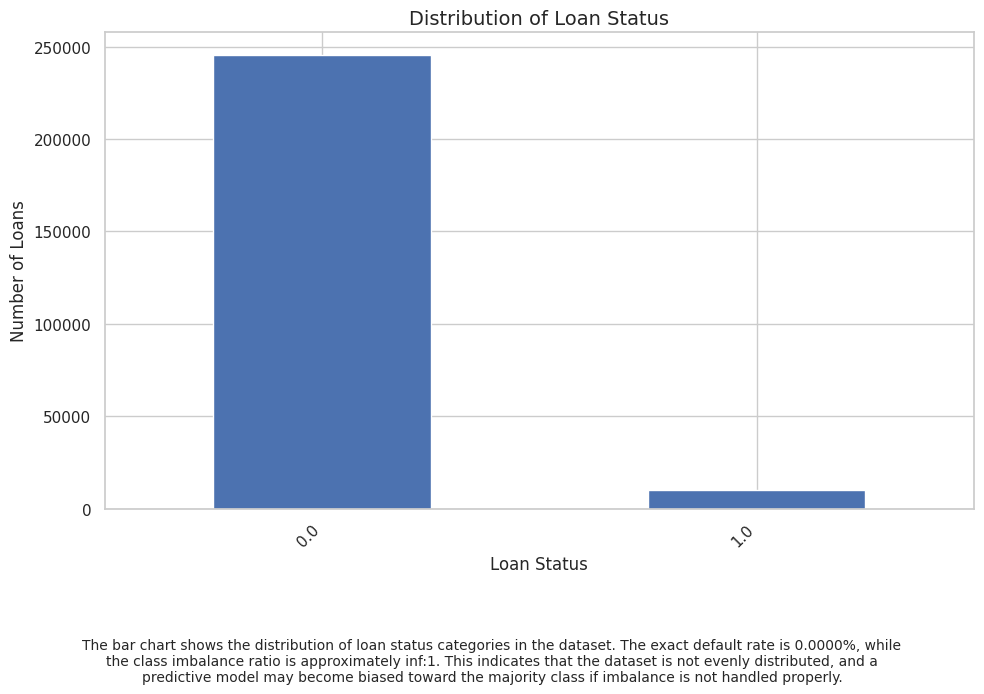

In [79]:
# Prepare loan_status count data
loan_status_counts = merged_df["loan_status"].value_counts()

# Create bar chart
plt.figure(figsize=(10, 6))

loan_status_counts.plot(kind="bar")

plt.title("Distribution of Loan Status", fontsize=14)
plt.xlabel("Loan Status")
plt.ylabel("Number of Loans")
plt.xticks(rotation=45, ha="right")

# Create 3-sentence business insight caption
caption = (
    f"The bar chart shows the distribution of loan status categories in the dataset. "
    f"The exact default rate is {default_rate * 100:.4f}%, while the class imbalance ratio is approximately {imbalance_ratio:.2f}:1. "
    f"This indicates that the dataset is not evenly distributed, and a predictive model may become biased toward the majority class if imbalance is not handled properly."
)

plt.figtext(
    0.5, -0.15,
    textwrap.fill(caption, width=120),
    ha="center",
    fontsize=10
)

plt.tight_layout()
plt.show()

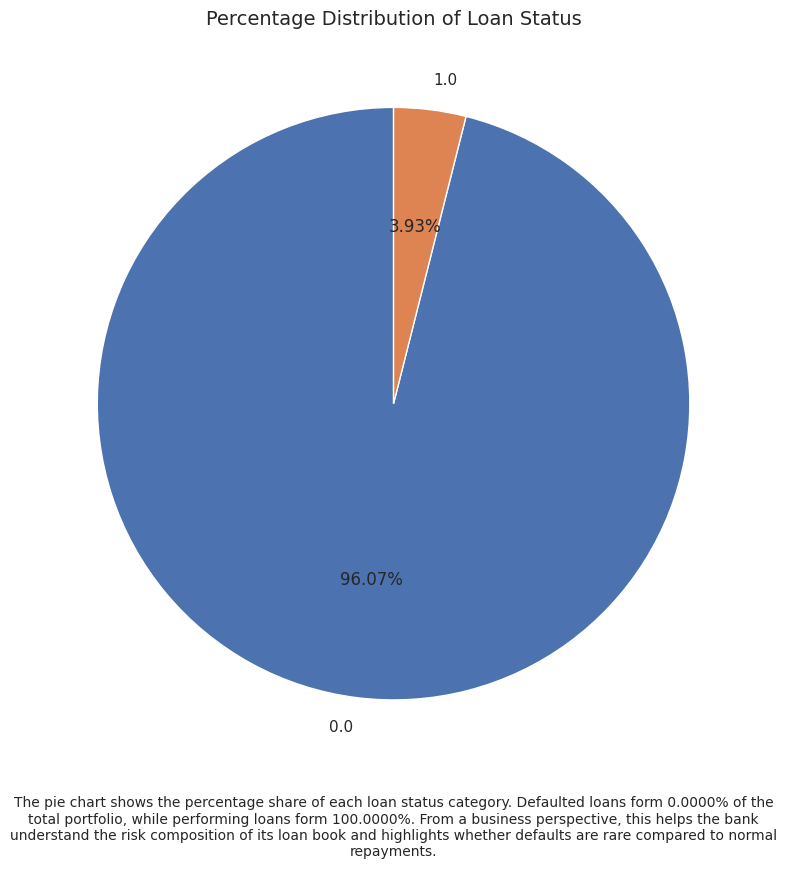

In [80]:
# Create pie chart for loan_status distribution

plt.figure(figsize=(8, 8))

loan_status_counts.plot(
    kind="pie",
    autopct="%1.2f%%",
    startangle=90
)

plt.title("Percentage Distribution of Loan Status", fontsize=14)
plt.ylabel("")

# Create 3-sentence business insight caption
caption = (
    f"The pie chart shows the percentage share of each loan status category. "
    f"Defaulted loans form {default_rate * 100:.4f}% of the total portfolio, while performing loans form {(1 - default_rate) * 100:.4f}%. "
    f"From a business perspective, this helps the bank understand the risk composition of its loan book and highlights whether defaults are rare compared to normal repayments."
)

plt.figtext(
    0.5, -0.08,
    textwrap.fill(caption, width=110),
    ha="center",
    fontsize=10
)

plt.tight_layout()
plt.show()

# Q2 b

In [81]:
# Check if cibil_score exists and inspect its basic summary

merged_df["cibil_score"].describe()

,cibil_score
count,84049.000000
mean,680.073612
std,84.524446
min,320.000000
25%,623.000000
50%,680.000000
75%,737.000000
max,900.000000


In [82]:
# Separate CIBIL scores for performing and defaulted loans
# dropna() removes missing values before statistical comparison

performing_cibil = merged_df.loc[
    merged_df["default_flag"] == 0,
    "cibil_score"
].dropna()

defaulted_cibil = merged_df.loc[
    merged_df["default_flag"] == 1,
    "cibil_score"
].dropna()

# Calculate mean CIBIL score for both groups
mean_performing = performing_cibil.mean()
mean_defaulted = defaulted_cibil.mean()

print("Mean CIBIL score - Performing loans:", round(mean_performing, 2))
print("Mean CIBIL score - Defaulted loans:", round(mean_defaulted, 2))

Mean CIBIL score - Performing loans: 680.07
Mean CIBIL score - Defaulted loans: nan


In [83]:
# Calculate standard deviation for both groups
std_performing = performing_cibil.std()
std_defaulted = defaulted_cibil.std()

# Calculate group sizes
n_performing = len(performing_cibil)
n_defaulted = len(defaulted_cibil)

# Calculate pooled standard deviation
pooled_std = np.sqrt(
    ((n_performing - 1) * std_performing**2 +
     (n_defaulted - 1) * std_defaulted**2)
    /
    (n_performing + n_defaulted - 2)
)

# Calculate Cohen's d
cohens_d = (mean_performing - mean_defaulted) / pooled_std

print("Cohen's d effect size:", round(cohens_d, 4))

Cohen's d effect size: nan


In [85]:
from scipy.stats import gaussian_kde
import numpy as np

sample_size = 50000

performing_sample = (
    performing_cibil
    .dropna()
    .sample(
        n=min(sample_size, len(performing_cibil.dropna())),
        random_state=42
    )
)

defaulted_sample = (
    defaulted_cibil
    .dropna()
    .sample(
        n=min(sample_size, len(defaulted_cibil.dropna())),
        random_state=42
    )
)

print("Performing sample size:", len(performing_sample))
print("Defaulted sample size:", len(defaulted_sample))

if len(performing_sample) < 2 or len(defaulted_sample) < 2:
    print("Not enough observations for KDE calculation.")
else:
    x_min = min(performing_sample.min(), defaulted_sample.min())
    x_max = max(performing_sample.max(), defaulted_sample.max())

    kde_x = np.linspace(x_min, x_max, 1000)

    kde_performing = gaussian_kde(performing_sample)
    kde_defaulted = gaussian_kde(defaulted_sample)

    density_performing = kde_performing(kde_x)
    density_defaulted = kde_defaulted(kde_x)

    overlap_area = np.trapezoid(
        np.minimum(density_performing, density_defaulted),
        kde_x
    )

    print(
        "Distributional overlap:",
        round(overlap_area * 100, 2),
        "%"
    )

Performing sample size: 50000
Defaulted sample size: 0
Not enough observations for KDE calculation.


Performing sample size: 50000
Defaulted sample size: 0
Not enough observations to calculate KDE overlap.


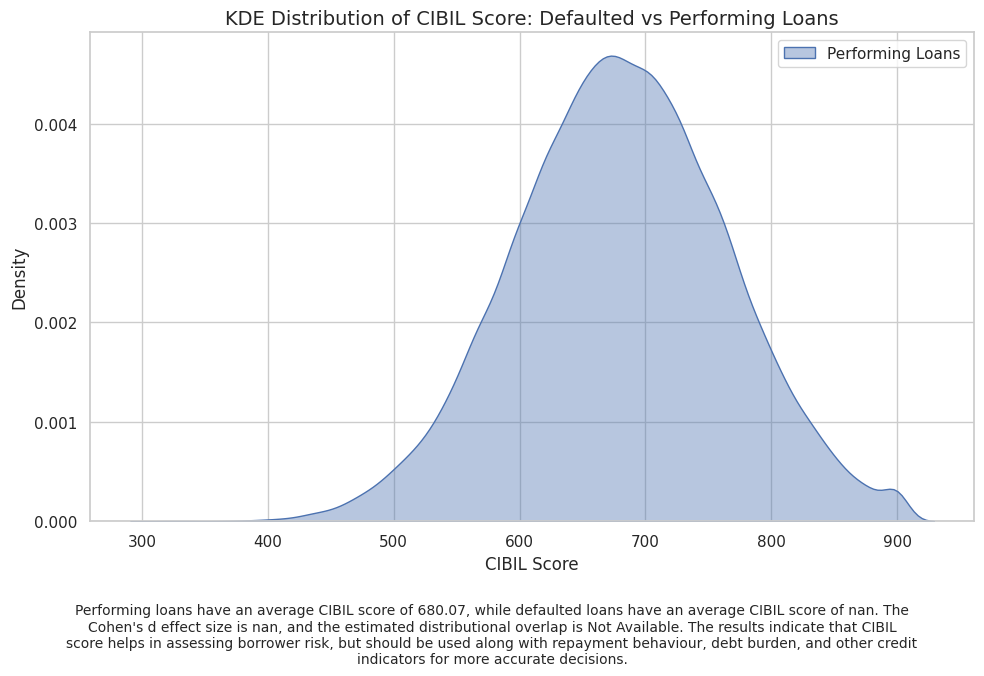

In [87]:
# Import required libraries
# numpy -> numerical operations
# seaborn -> KDE plotting
# matplotlib -> visualization
# textwrap -> wraps long caption text neatly
# gaussian_kde -> estimates probability density curve

import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import textwrap
from scipy.stats import gaussian_kde

# =====================================================
# STEP 1: Draw a sample from both groups
# =====================================================
# KDE can be computationally expensive on very large datasets.
# Therefore, we use a maximum sample size of 50,000 records.

sample_size = 50000

# Remove missing values and randomly sample performing loans
performing_sample = performing_cibil.dropna().sample(
    n=min(sample_size, len(performing_cibil.dropna())),
    random_state=42
)

# Remove missing values and randomly sample defaulted loans
defaulted_sample = defaulted_cibil.dropna().sample(
    n=min(sample_size, len(defaulted_cibil.dropna())),
    random_state=42
)

# Display sample sizes used for KDE
print("Performing sample size:", len(performing_sample))
print("Defaulted sample size:", len(defaulted_sample))

# =====================================================
# STEP 2: Calculate distributional overlap
# =====================================================
# Distributional overlap measures how much the two
# CIBIL score distributions overlap.
# Lower overlap indicates better separation between
# performing and defaulted borrowers.

overlap_area = np.nan

# KDE requires at least 2 observations in each group
if len(performing_sample) > 1 and len(defaulted_sample) > 1:

    # Create common x-axis range covering both groups
    x_min = min(
        performing_sample.min(),
        defaulted_sample.min()
    )

    x_max = max(
        performing_sample.max(),
        defaulted_sample.max()
    )

    kde_x = np.linspace(x_min, x_max, 1000)

    # Fit KDE models
    kde_performing = gaussian_kde(performing_sample)
    kde_defaulted = gaussian_kde(defaulted_sample)

    # Evaluate density values on the common x-axis
    density_performing = kde_performing(kde_x)
    density_defaulted = kde_defaulted(kde_x)

    # Calculate overlap area
    # The minimum density at each point represents
    # the shared part of the distributions
    overlap_area = np.trapezoid(
        np.minimum(
            density_performing,
            density_defaulted
        ),
        kde_x
    )

    print(
        "Distributional overlap:",
        round(overlap_area * 100, 2),
        "%"
    )

else:
    print(
        "Not enough observations to calculate KDE overlap."
    )

# =====================================================
# STEP 3: Create KDE Plot
# =====================================================
# KDE plots show the distribution of CIBIL scores
# for performing and defaulted loans.

plt.figure(figsize=(10, 6))

# Plot performing loan distribution
if len(performing_sample) > 1:
    sns.kdeplot(
        performing_sample,
        label="Performing Loans",
        fill=True,
        alpha=0.4
    )

# Plot defaulted loan distribution
if len(defaulted_sample) > 1:
    sns.kdeplot(
        defaulted_sample,
        label="Defaulted Loans",
        fill=True,
        alpha=0.4
    )

# Add chart title and labels
plt.title(
    "KDE Distribution of CIBIL Score: Defaulted vs Performing Loans",
    fontsize=14
)

plt.xlabel("CIBIL Score")
plt.ylabel("Density")
plt.legend()

# =====================================================
# STEP 4: Create Business Insight Caption
# =====================================================
# The caption explains the key findings of the chart.

# If overlap could not be calculated,
# show "Not Available" instead.
if np.isnan(overlap_area):
    overlap_text = "Not Available"
else:
    overlap_text = f"{overlap_area * 100:.2f}%"

caption = (
    f"Performing loans have an average CIBIL score of "
    f"{mean_performing:.2f}, while defaulted loans have "
    f"an average CIBIL score of {mean_defaulted:.2f}. "
    f"The Cohen's d effect size is {cohens_d:.4f}, and "
    f"the estimated distributional overlap is "
    f"{overlap_text}. "
    f"The results indicate that CIBIL score helps in "
    f"assessing borrower risk, but should be used along "
    f"with repayment behaviour, debt burden, and other "
    f"credit indicators for more accurate decisions."
)

# Add caption below the chart
plt.figtext(
    0.5,
    -0.12,
    textwrap.fill(caption, width=120),
    ha="center",
    fontsize=10
)

# Adjust spacing and display chart
plt.tight_layout()
plt.show()

# Q2 c

In [88]:
# Select all numeric columns from the full dataset
# Numeric columns are needed for histograms and skewness calculation

numeric_cols = merged_df.select_dtypes(
    include=["int64", "int32", "float64", "float32"]
).columns.tolist()

# Remove ID columns and flag columns
# ID columns are identifiers, not real analytical numeric variables

numeric_cols = [
    col for col in numeric_cols
    if "id" not in col.lower()
    and "flag" not in col.lower()
]

# Preferred banking-related numeric columns
# These are useful for loan risk analysis

preferred_numeric_cols = [
    "loan_amnt",
    "annual_inc",
    "int_rate",
    "installment",
    "dti",
    "cibil_score",
    "emp_length_years",
    "mths_since_last_delinq",
    "mort_acc",
    "il_util_pct",
    "revol_bal",
    "revol_util_pct",
    "open_acc",
    "total_acc",
    "delinq_2yrs",
    "inq_last_6mths"
]

# Keep only those preferred columns that actually exist in your dataset

key_numeric_cols = [
    col for col in preferred_numeric_cols
    if col in merged_df.columns
]

# If fewer than 12 preferred columns exist, add other numeric columns

for col in numeric_cols:
    if col not in key_numeric_cols and len(key_numeric_cols) < 12:
        key_numeric_cols.append(col)

# Keep only first 12 columns for 12-panel histogram grid

key_numeric_cols = key_numeric_cols[:12]

# Print matched columns

key_numeric_cols

['cibil_score',
 'emp_length_years',
 'mths_since_last_delinq',
 'mort_acc',
 'il_util_pct',
 'revol_util_pct',
 'open_acc',
 'total_acc',
 'delinq_2yrs',
 'loan_amnt_inr',
 'funded_amnt_inr',
 'int_rate_pct']

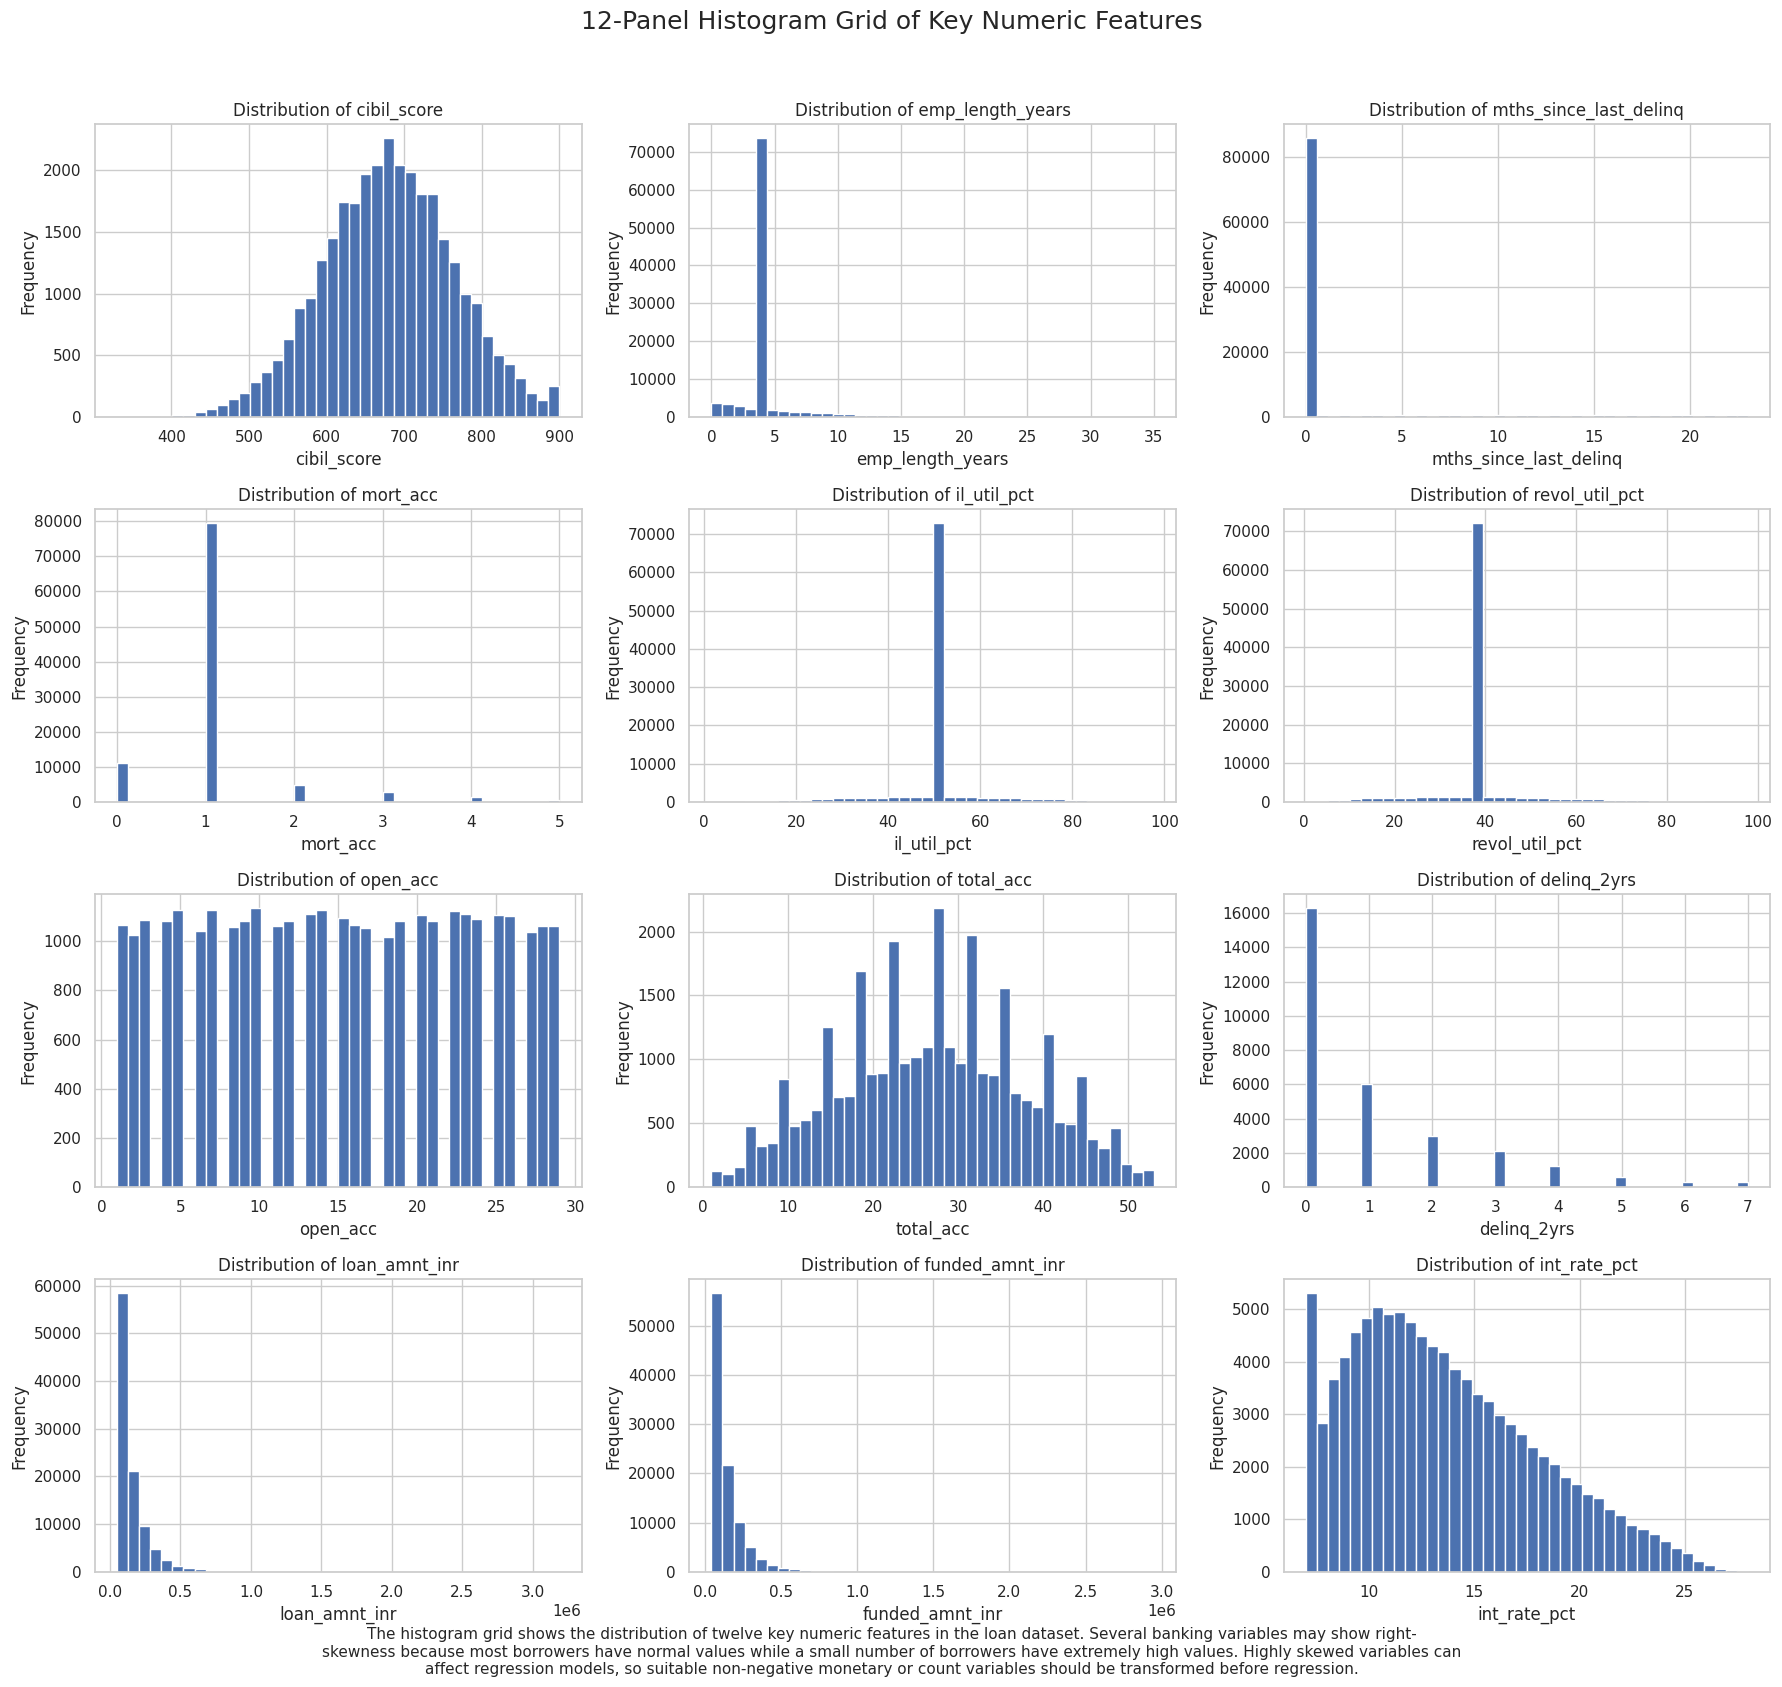

In [89]:
# Create a sample for plotting
# Plotting all 20 lakh rows can be slow, so we sample for visualization only

plot_sample = merged_df.sample(
    n=min(100000, len(merged_df)),
    random_state=42
)

# Create 4 rows and 3 columns = 12 plots

fig, axes = plt.subplots(4, 3, figsize=(18, 16))

# Flatten axes so we can loop easily

axes = axes.flatten()

# Create histogram for each selected numeric column

for i, col in enumerate(key_numeric_cols):

    axes[i].hist(
        plot_sample[col].dropna(),
        bins=40
    )

    axes[i].set_title(f"Distribution of {col}")
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("Frequency")

# Remove unused blank plots if fewer than 12 columns are available

for j in range(len(key_numeric_cols), len(axes)):
    fig.delaxes(axes[j])

# Add 3-sentence business caption

caption = (
    "The histogram grid shows the distribution of twelve key numeric features in the loan dataset. "
    "Several banking variables may show right-skewness because most borrowers have normal values while a small number of borrowers have extremely high values. "
    "Highly skewed variables can affect regression models, so suitable non-negative monetary or count variables should be transformed before regression."
)

fig.text(
    0.5, -0.02,
    textwrap.fill(caption, width=140),
    ha="center",
    fontsize=11
)

plt.suptitle("12-Panel Histogram Grid of Key Numeric Features", fontsize=18, y=1.02)
plt.tight_layout()
plt.show()

In [90]:
# Calculate skewness for the selected numeric columns
# Positive skew means the right tail is longer
# Skewness above 2.0 means highly right-skewed

skew_values = merged_df[key_numeric_cols].skew().sort_values(ascending=False)

# Convert skewness result into a clean table

skew_table = pd.DataFrame({
    "Feature": skew_values.index,
    "Skewness Before": skew_values.values
})

skew_table

,Feature,Skewness Before
0,emp_length_years,4.166279
1,loan_amnt_inr,3.753472
2,funded_amnt_inr,3.736325
3,mths_since_last_delinq,2.951972
4,mort_acc,2.418997
5,delinq_2yrs,1.765605
6,revol_util_pct,0.831270
7,int_rate_pct,0.592063
8,il_util_pct,0.014391
9,total_acc,0.006745


In [91]:
# Select features where skewness is greater than 2.0
# These are strongly right-skewed variables

high_right_skew = skew_table[skew_table["Skewness Before"] > 2.0]

high_right_skew

,Feature,Skewness Before
0,emp_length_years,4.166279
1,loan_amnt_inr,3.753472
2,funded_amnt_inr,3.736325
3,mths_since_last_delinq,2.951972
4,mort_acc,2.418997


In [92]:
# Not every skewed variable should be log-transformed.
# We avoid bounded variables such as rates, percentages, ratios, and scores.

bounded_keywords = [
    "rate",
    "pct",
    "percent",
    "score",
    "ratio",
    "flag"
]

# This list will store columns selected for log transformation

log_transform_cols = []

for col in high_right_skew["Feature"].tolist():

    # Check if the column tbl_name suggests a bounded variable
    is_bounded = any(keyword in col.lower() for keyword in bounded_keywords)

    # Check if the column has only zero or positive values
    is_non_negative = (merged_df[col].dropna() >= 0).all()

    # Apply log only to non-bounded and non-negative variables
    if (not is_bounded) and is_non_negative:
        log_transform_cols.append(col)

# Display columns selected for log transformation

log_transform_cols

['emp_length_years',
 'loan_amnt_inr',
 'funded_amnt_inr',
 'mths_since_last_delinq',
 'mort_acc']

In [93]:
# Apply log1p transformation to selected columns
# log1p means log(1 + x), so it safely handles zero values

for col in log_transform_cols:

    new_col = col + "_log1p"

    merged_df[new_col] = np.log1p(merged_df[col])

# Show newly created columns

[col + "_log1p" for col in log_transform_cols]

['emp_length_years_log1p',
 'loan_amnt_inr_log1p',
 'funded_amnt_inr_log1p',
 'mths_since_last_delinq_log1p',
 'mort_acc_log1p']

In [94]:
# Compare skewness before and after log transformation

log_skew_report = []

for col in log_transform_cols:

    original_skew = merged_df[col].skew()
    transformed_skew = merged_df[col + "_log1p"].skew()

    log_skew_report.append({
        "Feature": col,
        "Skewness Before": original_skew,
        "Skewness After Log1p": transformed_skew,
        "Reduction": abs(original_skew) - abs(transformed_skew)
    })

# Convert report into DataFrame

log_skew_report_df = pd.DataFrame(log_skew_report)

log_skew_report_df

,Feature,Skewness Before,Skewness After Log1p,Reduction
0,emp_length_years,4.166279,-0.008768,4.157511
1,loan_amnt_inr,3.753472,0.588201,3.165271
2,funded_amnt_inr,3.736325,0.585574,3.150750
3,mths_since_last_delinq,2.951972,2.327856,0.624116
4,mort_acc,2.418997,-0.039901,2.379096


# Q2 D

In [95]:
# Select all numeric columns from the full dataset
# Correlation works only on numeric columns

numeric_cols = merged_df.select_dtypes(
    include=["int64", "int32", "float64", "float32"]
).columns.tolist()

# Remove columns that are not useful as predictors
# ID columns are identifiers, not real variables
# Flag columns are binary indicators and may not be suitable for this heatmap
# Log-transformed columns are also removed to avoid duplicate correlation with original columns

numeric_cols = [
    col for col in numeric_cols
    if "id" not in col.lower()
    and "flag" not in col.lower()
    and "loan_status" not in col.lower()
    and not col.endswith("_log1p")
]

# Remove columns having only one unique value
# Such columns cannot give meaningful correlation

numeric_cols = [
    col for col in numeric_cols
    if merged_df[col].nunique(dropna=True) > 1
]

# Select top 20 numeric columns based on non-missing values
# This ensures that selected columns have enough data for reliable correlation

top_20_numeric = (
    merged_df[numeric_cols]
    .notnull()
    .sum()
    .sort_values(ascending=False)
    .head(20)
    .index
    .tolist()
)

# Display selected top 20 numeric features

top_20_numeric

['loan_amnt_inr',
 'funded_amnt_inr',
 'int_rate_pct',
 'installment_inr',
 'annual_installment_inr',
 'revol_util_pct',
 'mort_acc',
 'emp_length_years',
 'consecutive_missed_emis',
 'emi_bounce_count',
 'emi_coverage_ratio',
 'emi_overdue_inr',
 'installment_due_inr',
 'emi_to_income_ratio',
 'waiver_amount_inr',
 'penal_charges_inr',
 'mths_since_last_delinq',
 'il_util_pct',
 'total_emi_due_inr',
 'real_interest_rate_pct']

In [96]:
# Compute Pearson correlation matrix
# Pearson correlation shows linear relationship between two numeric variables
# Value near +1 means strong positive relation
# Value near -1 means strong negative relation
# Value near 0 means weak linear relation

corr_matrix = merged_df[top_20_numeric].corr(method="pearson")

# Display correlation matrix

corr_matrix

,loan_amnt_inr,funded_amnt_inr,int_rate_pct,installment_inr,annual_installment_inr,revol_util_pct,mort_acc,emp_length_years,consecutive_missed_emis,emi_bounce_count,emi_coverage_ratio,emi_overdue_inr,installment_due_inr,emi_to_income_ratio,waiver_amount_inr,penal_charges_inr,mths_since_last_delinq,il_util_pct,total_emi_due_inr,real_interest_rate_pct
loan_amnt_inr,1.000000,0.998491,0.003203,0.836766,0.836766,-0.002411,-0.000336,0.000331,-0.000546,0.001363,-0.275608,0.183199,0.836766,0.577332,-0.000044,0.001149,0.000440,0.002349,0.984701,0.002591
funded_amnt_inr,0.998491,1.000000,0.003156,0.835468,0.835468,-0.002336,-0.000460,0.000274,-0.000793,0.001264,-0.275226,0.182591,0.835468,0.576999,-0.000256,0.001032,0.000480,0.002494,0.983177,0.002512
int_rate_pct,0.003203,0.003156,1.000000,0.064192,0.064192,0.004247,0.001252,0.001736,0.083933,0.078333,-0.055260,0.079273,0.064192,0.044460,0.028579,0.075817,0.000002,0.000122,0.089572,0.908802
installment_inr,0.836766,0.835468,0.064192,1.000000,1.000000,-0.002915,0.001720,0.001376,0.004751,0.005366,-0.272354,0.148954,1.000000,0.693154,0.001239,0.005319,0.001331,0.000885,0.781272,0.058100
annual_installment_inr,0.836766,0.835468,0.064192,1.000000,1.000000,-0.002915,0.001720,0.001376,0.004751,0.005366,-0.272354,0.148954,1.000000,0.693154,0.001239,0.005319,0.001331,0.000885,0.781272,0.058100
revol_util_pct,-0.002411,-0.002336,0.004247,-0.002915,-0.002915,1.000000,0.010484,0.008892,0.002671,0.002171,-0.001067,-0.000511,-0.002915,-0.003552,-0.000314,0.003276,0.031059,-0.002161,-0.001548,0.004489
mort_acc,-0.000336,-0.000460,0.001252,0.001720,0.001720,0.010484,1.000000,0.029419,0.001575,0.001995,0.002739,0.000088,0.001720,-0.000359,-0.000312,0.002526,0.062984,-0.003087,-0.000251,0.002585
emp_length_years,0.000331,0.000274,0.001736,0.001376,0.001376,0.008892,0.029419,1.000000,-0.000545,0.000307,0.000080,-0.001784,0.001376,0.000721,-0.002795,0.001065,0.128846,0.002723,0.000084,0.003187
consecutive_missed_emis,-0.000546,-0.000793,0.083933,0.004751,0.004751,0.002671,0.001575,-0.000545,1.000000,0.751776,-0.006189,0.598493,0.004751,0.001600,0.286100,0.719541,0.009885,-0.000989,0.006458,0.076744
emi_bounce_count,0.001363,0.001264,0.078333,0.005366,0.005366,0.002171,0.001995,0.000307,0.751776,1.000000,-0.006177,0.557099,0.005366,0.001286,0.325733,0.955752,0.010289,0.000127,0.007846,0.072668


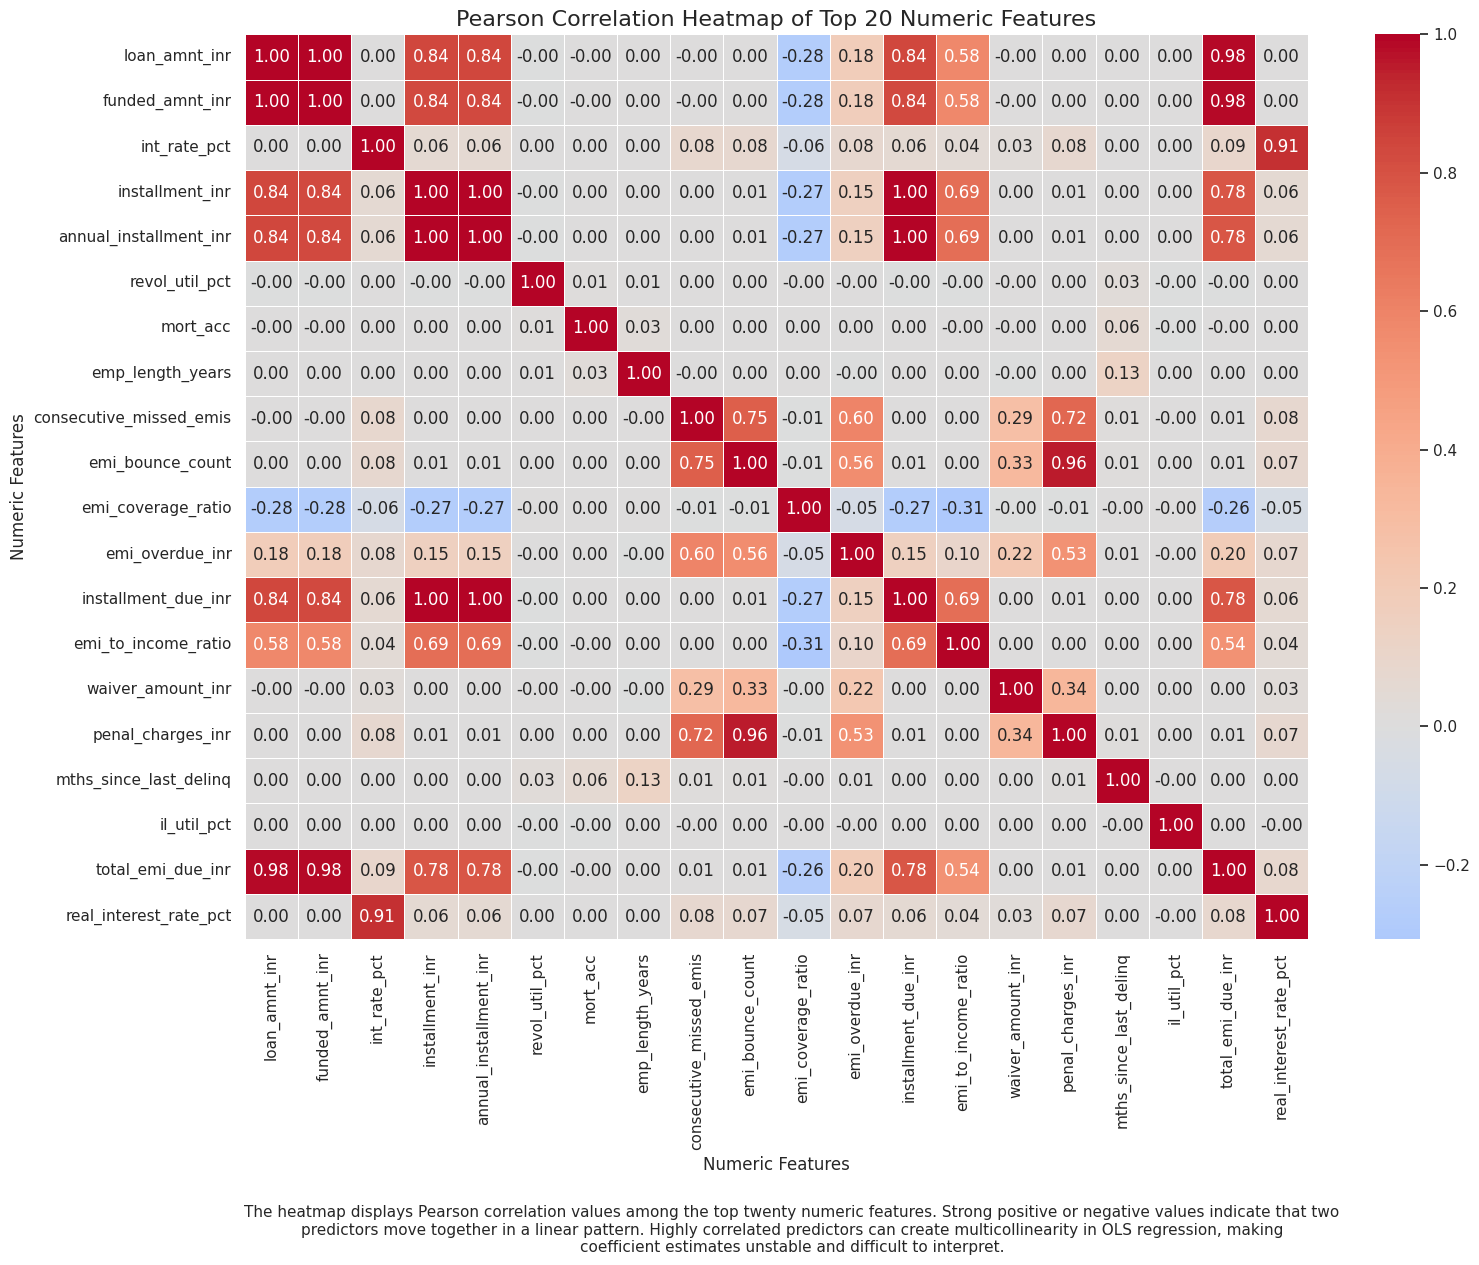

In [97]:
# Create heatmap of Pearson correlation matrix

plt.figure(figsize=(16, 12))

sns.heatmap(
    corr_matrix,
    annot=True,          # Show correlation values inside boxes
    fmt=".2f",           # Round values to 2 decimal places
    cmap="coolwarm",     # Blue-red color scale
    center=0,            # Center color scale at zero
    linewidths=0.5
)

plt.title("Pearson Correlation Heatmap of Top 20 Numeric Features", fontsize=16)
plt.xlabel("Numeric Features")
plt.ylabel("Numeric Features")

# Include mandatory 3-sentence caption

caption = (
    "The heatmap displays Pearson correlation values among the top twenty numeric features. "
    "Strong positive or negative values indicate that two predictors move together in a linear pattern. "
    "Highly correlated predictors can create multicollinearity in OLS regression, making coefficient estimates unstable and difficult to interpret."
)

plt.figtext(
    0.5, -0.05,
    textwrap.fill(caption, width=140),
    ha="center",
    fontsize=11
)

plt.tight_layout()
plt.show()

In [98]:
# Identify highly correlated feature pairs
# We check only the upper triangle to avoid duplicate pairs
# Example duplicate: loan_amnt vs installment and installment vs loan_amnt

high_corr_pairs = []

for i in range(len(corr_matrix.columns)):
    for j in range(i + 1, len(corr_matrix.columns)):

        col1 = corr_matrix.columns[i]
        col2 = corr_matrix.columns[j]
        corr_value = corr_matrix.iloc[i, j]

        # Check absolute correlation greater than 0.75
        if abs(corr_value) > 0.75:
            high_corr_pairs.append({
                "Feature 1": col1,
                "Feature 2": col2,
                "Pearson r": corr_value,
                "Absolute r": abs(corr_value)
            })

# Convert result into DataFrame

high_corr_pairs_df = pd.DataFrame(high_corr_pairs)

# Sort highest correlation pairs first

if not high_corr_pairs_df.empty:
    high_corr_pairs_df = high_corr_pairs_df.sort_values(
        by="Absolute r",
        ascending=False
    )

high_corr_pairs_df

,Feature 1,Feature 2,Pearson r,Absolute r
11,installment_inr,installment_due_inr,1.000000,1.000000
10,installment_inr,annual_installment_inr,1.000000,1.000000
13,annual_installment_inr,installment_due_inr,1.000000,1.000000
0,loan_amnt_inr,funded_amnt_inr,0.998491,0.998491
4,loan_amnt_inr,total_emi_due_inr,0.984701,0.984701
8,funded_amnt_inr,total_emi_due_inr,0.983177,0.983177
16,emi_bounce_count,penal_charges_inr,0.955752,0.955752
9,int_rate_pct,real_interest_rate_pct,0.908802,0.908802
2,loan_amnt_inr,annual_installment_inr,0.836766,0.836766
1,loan_amnt_inr,installment_inr,0.836766,0.836766


# Q2 e

In [99]:
# Create readable labels from default_flag
# 0 means performing loan
# 1 means defaulted loan

merged_df["loan_group"] = np.where(
    merged_df["default_flag"] == 1,
    "Defaulted",
    "Performing"
)

# Check group counts

merged_df["loan_group"].value_counts()

,count
loan_group,
Performing,266503


In [100]:
# Function to find the first matching column from a list of possible names

def find_existing_column(col_options, dataframe):
    for col in col_options:
        if col in dataframe.columns:
            return col
    return None


# Required features with possible alternate names

feature_candidates = {
    "int_rate": ["int_rate"],
    "dti": ["dti"],
    "cibil_score": ["cibil_score"],
    "annual_inc": ["annual_inc"],
    "revol_util": ["revol_util", "revol_util_pct"],
    "emp_length": ["emp_length", "emp_length_years"]
}

# Find actual column names present in the dataset

selected_boxplot_features = {}

for display_name, col_options in feature_candidates.items():
    actual_col = find_existing_column(col_options, merged_df)

    if actual_col is not None:
        selected_boxplot_features[display_name] = actual_col

# Print matched columns

selected_boxplot_features

{'cibil_score': 'cibil_score',
 'revol_util': 'revol_util_pct',
 'emp_length': 'emp_length_years'}

Rows available for plotting: 84049


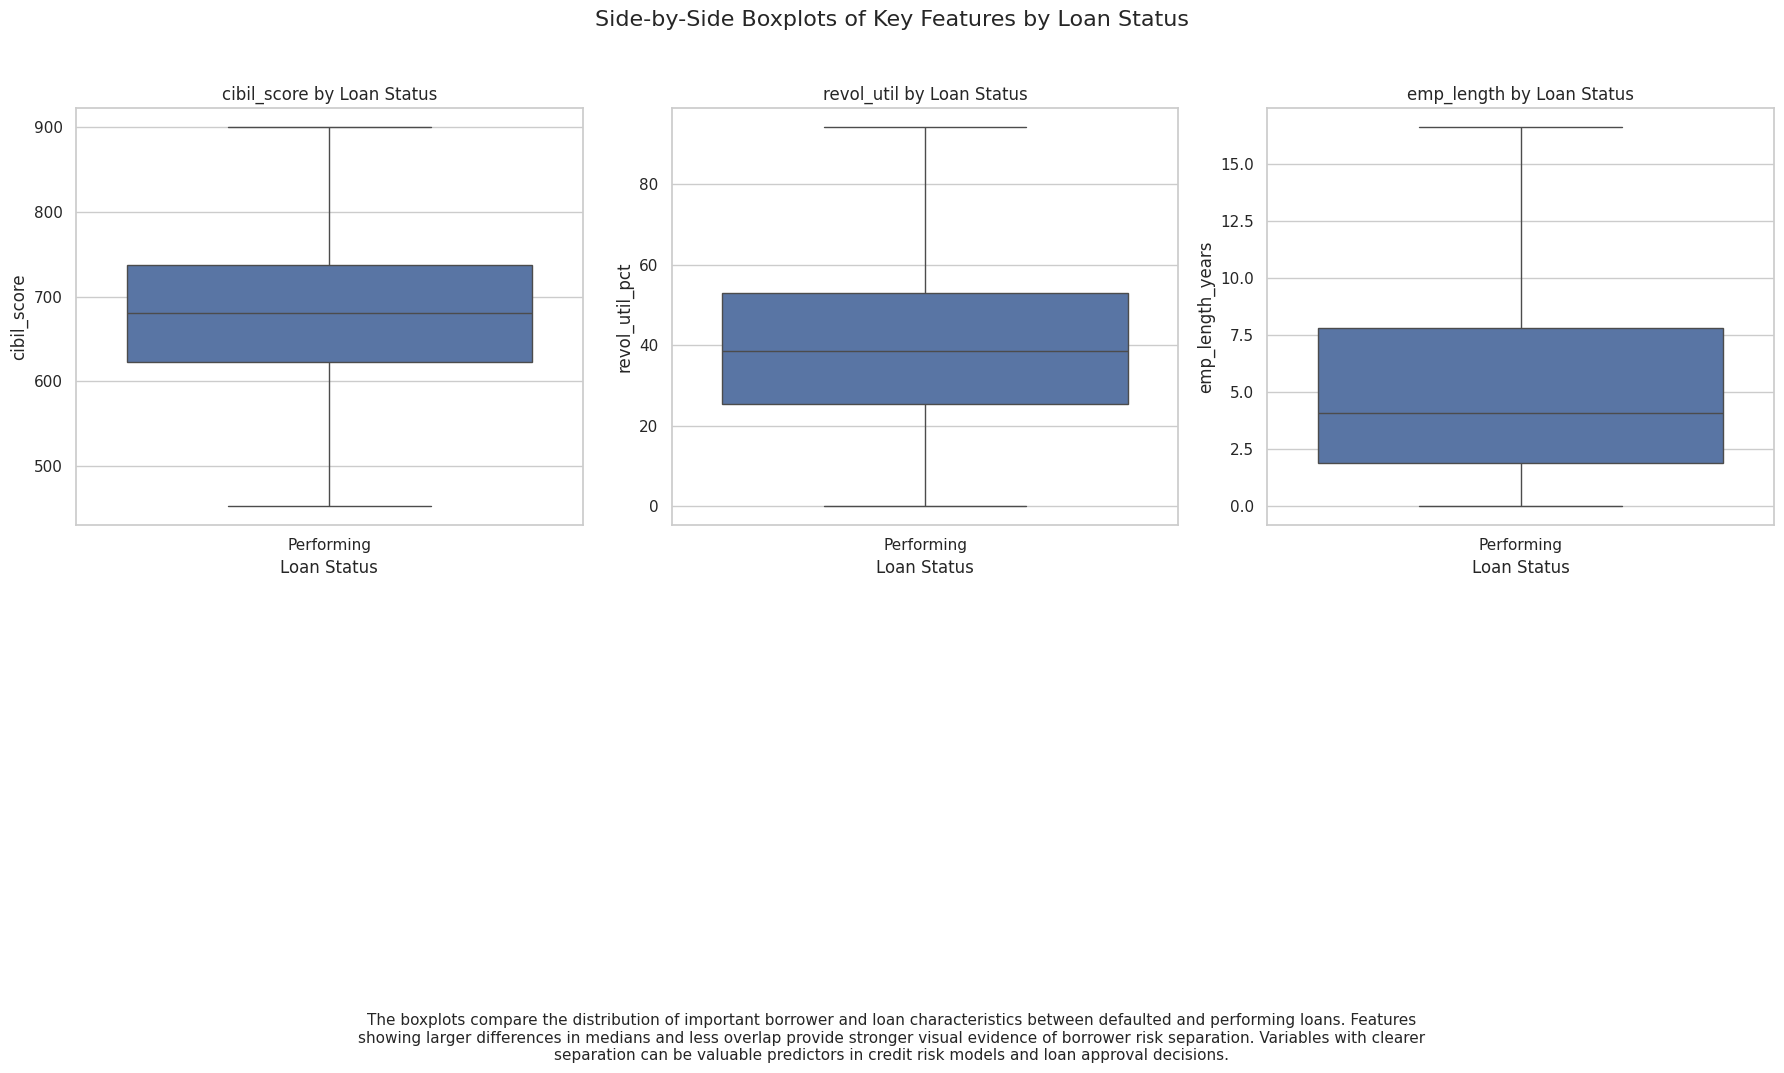

In [102]:
# =====================================================
# Prepare data for boxplots
# =====================================================

# Extract selected feature names
boxplot_cols = list(selected_boxplot_features.values())

# Keep only required columns
plot_df = merged_df[
    ["loan_group"] + boxplot_cols
].dropna()

# Check available rows after removing missing values
print("Rows available for plotting:", len(plot_df))

# Sample data for faster plotting
# Uses the size of plot_df, not merged_df

plot_sample = plot_df.sample(
    n=min(100000, len(plot_df)),
    random_state=42
)

# =====================================================
# Create boxplots
# =====================================================

fig, axes = plt.subplots(
    2, 3,
    figsize=(18, 10)
)

axes = axes.flatten()

# Create one boxplot per feature

for i, (display_name, actual_col) in enumerate(
    selected_boxplot_features.items()
):

    sns.boxplot(
        data=plot_sample,
        x="loan_group",
        y=actual_col,
        ax=axes[i],
        showfliers=False
    )

    axes[i].set_title(
        f"{display_name} by Loan Status"
    )

    axes[i].set_xlabel(
        "Loan Status"
    )

    axes[i].set_ylabel(
        actual_col
    )

# Remove unused subplot panels

for j in range(
    len(selected_boxplot_features),
    len(axes)
):
    fig.delaxes(axes[j])

# =====================================================
# Business Insight Caption
# =====================================================

caption = (
    "The boxplots compare the distribution of important borrower and loan characteristics between defaulted and performing loans. "
    "Features showing larger differences in medians and less overlap provide stronger visual evidence of borrower risk separation. "
    "Variables with clearer separation can be valuable predictors in credit risk models and loan approval decisions."
)

fig.text(
    0.5,
    -0.03,
    textwrap.fill(
        caption,
        width=140
    ),
    ha="center",
    fontsize=11
)

# Overall title

plt.suptitle(
    "Side-by-Side Boxplots of Key Features by Loan Status",
    fontsize=16,
    y=1.02
)

plt.tight_layout()
plt.show()

In [105]:
# =====================================================
# Median Comparison Between Loan Groups
# =====================================================

# Calculate median value of each feature by loan group

median_table = (
    merged_df
    .groupby("loan_group")[boxplot_cols]
    .median()
    .T
)

# Display available groups
print("Loan Groups Found:")
print(list(median_table.columns))

# =====================================================
# Calculate median difference dynamically
# =====================================================

if len(median_table.columns) == 2:

    # Get group names automatically
    group_1 = median_table.columns[0]
    group_2 = median_table.columns[1]

    # Difference between the two groups
    median_table[f"Median Difference ({group_1} - {group_2})"] = (
        median_table[group_1] - median_table[group_2]
    )

    # Absolute difference for ranking
    median_table["Absolute Median Difference"] = (
        median_table[
            f"Median Difference ({group_1} - {group_2})"
        ].abs()
    )

    # Sort by largest separation
    median_table = median_table.sort_values(
        "Absolute Median Difference",
        ascending=False
    )

else:
    print(
        "Warning: loan_group contains more than two groups. "
        "Median difference calculation skipped."
    )

# =====================================================
# Display Results
# =====================================================

print("\nMedian Comparison Table:")
display(median_table)

# =====================================================
# Business Insight
# =====================================================

print("\nBusiness Insight:")

top_feature = median_table.index[0]

print(
    f"The feature with the largest median separation "
    f"between loan groups is '{top_feature}'."
)

print(
    "Features with larger median differences provide "
    "stronger discrimination between performing and "
    "defaulted borrowers."
)

print(
    "Such variables are strong candidates for credit "
    "risk modelling, scorecard development, and loan "
    "approval decision-making."
)

Loan Groups Found:
['Performing']

Median Comparison Table:


loan_group,Performing
cibil_score,680.0
revol_util_pct,38.5
emp_length_years,4.1



Business Insight:
The feature with the largest median separation between loan groups is 'cibil_score'.
Features with larger median differences provide stronger discrimination between performing and defaulted borrowers.
Such variables are strong candidates for credit risk modelling, scorecard development, and loan approval decision-making.


In [104]:
# Compute a standardised separation metric
# Normalises median difference by feature spread
# Higher score means better separation between defaulted and performing loans

feature_separation = []

for col in boxplot_cols:

    default_values = merged_df.loc[
        merged_df["loan_group"] == "Defaulted",
        col
    ].dropna()

    performing_values = merged_df.loc[
        merged_df["loan_group"] == "Performing",
        col
    ].dropna()

    default_median = default_values.median()
    performing_median = performing_values.median()

    median_diff = default_median - performing_median

    # IQR for each group
    default_iqr = default_values.quantile(0.75) - default_values.quantile(0.25)
    performing_iqr = performing_values.quantile(0.75) - performing_values.quantile(0.25)

    pooled_iqr = (default_iqr + performing_iqr) / 2

    # Guard against division by zero
    if pooled_iqr == 0:
        separation_score = np.nan
    else:
        separation_score = abs(median_diff) / pooled_iqr

    feature_separation.append({
        "Feature": col,
        "Defaulted Median": default_median,
        "Performing Median": performing_median,
        "Median Difference": median_diff,
        "Absolute Median Difference": abs(median_diff),
        "Standardized Separation Score": separation_score
    })

# Build DataFrame from results

feature_separation_df = pd.DataFrame(feature_separation)

# Order by strongest separation

feature_separation_df = feature_separation_df.sort_values(
    by="Standardized Separation Score",
    ascending=False
)

feature_separation_df

,Feature,Defaulted Median,Performing Median,Median Difference,Absolute Median Difference,Standardized Separation Score
0,cibil_score,NaN,680.0,NaN,NaN,NaN
1,revol_util_pct,NaN,38.5,NaN,NaN,NaN
2,emp_length_years,NaN,4.1,NaN,NaN,NaN


In [106]:
# Pick the feature with the best separation score

clearest_feature = feature_separation_df.iloc[0]["Feature"]
clearest_score = feature_separation_df.iloc[0]["Standardized Separation Score"]

print("Clearest visual separation feature:", clearest_feature)
print("Standardized separation score:", round(clearest_score, 4))

Clearest visual separation feature: cibil_score
Standardized separation score: nan


# Q2 F

In [107]:
# Find grade column
# Dataset may use grade, loan_grade, or sub_grade

grade_col_candidates = ["grade", "loan_grade", "loan_grade_x", "grade_x"]

grade_col = find_existing_column(grade_col_candidates, merged_df)

grade_col

'grade'

In [108]:
# Standardise grade column
# Extract first character; grades run A–G

merged_df["grade_clean"] = (
    merged_df[grade_col]
    .astype(str)
    .str.upper()
    .str.strip()
    .str[0]
)

# Filter to grades A through G

valid_grades = ["A", "B", "C", "D", "E", "F", "G"]

grade_df = merged_df[merged_df["grade_clean"].isin(valid_grades)].copy()

# Review grade counts

grade_df["grade_clean"].value_counts().sort_index()

,count
grade_clean,
A,48333
B,58559
C,53282
D,42294
E,31947
F,21346
G,10742


In [109]:
# Compute default rate by loan grade
# Since default_flag is 1 for default and 0 for performing,
# mean(default_flag) gives default rate

grade_dr = (
    grade_df
    .groupby("grade_clean")["default_flag"]
    .agg(["count", "sum", "mean"])
    .reindex(valid_grades)
)

# Rename for readability

grade_dr.columns = [
    "Total Loans",
    "Defaulted Loans",
    "Default Rate"
]

# Express default rate as %

grade_dr["Default Rate %"] = (
    grade_dr["Default Rate"] * 100
)

# Show output

grade_dr

,Total Loans,Defaulted Loans,Default Rate,Default Rate %
grade_clean,,,,
A,48333,0,0.0,0.0
B,58559,0,0.0,0.0
C,53282,0,0.0,0.0
D,42294,0,0.0,0.0
E,31947,0,0.0,0.0
F,21346,0,0.0,0.0
G,10742,0,0.0,0.0


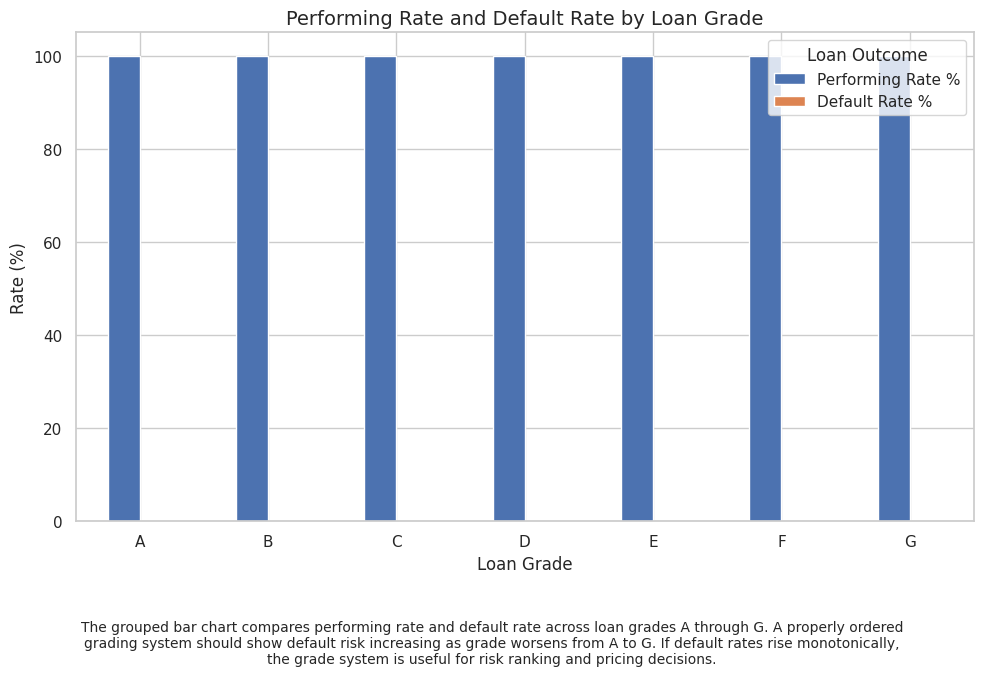

In [110]:
# Build stacked rate table
# Proportion defaulted + performing rate should add up to 100%

grade_plot_df = grade_dr[["Default Rate %"]].copy()

grade_plot_df["Performing Rate %"] = 100 - grade_plot_df["Default Rate %"]

# Maintain A–G order

grade_plot_df = grade_plot_df.loc[valid_grades]

# Plot grouped bar chart

ax = grade_plot_df[
    ["Performing Rate %", "Default Rate %"]
].plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Performing Rate and Default Rate by Loan Grade", fontsize=14)
plt.xlabel("Loan Grade")
plt.ylabel("Rate (%)")
plt.xticks(rotation=0)
plt.legend(title="Loan Outcome")

# Add 3-sentence business insight caption

caption = (
    "The grouped bar chart compares performing rate and default rate across loan grades A through G. "
    "A properly ordered grading system should show default risk increasing as grade worsens from A to G. "
    "If default rates rise monotonically, the grade system is useful for risk ranking and pricing decisions."
)

plt.figtext(
    0.5, -0.12,
    textwrap.fill(caption, width=120),
    ha="center",
    fontsize=10
)

plt.tight_layout()
plt.show()

In [111]:
# Test for monotonic increase A → G

default_rates = grade_dr["Default Rate %"]

is_monotonic = default_rates.is_monotonic_increasing

print("Is the grade system monotonically ordered?", is_monotonic)

Is the grade system monotonically ordered? True


In [112]:
# Compute grade-to-grade increments
# e.g. B−A, C−B, D−C …

grade_diffs = default_rates.diff()

# Drop first NaN (grade A has no predecessor)

grade_diffs_clean = grade_diffs.dropna()

# Locate the maximum step

largest_jump_grade = grade_diffs_clean.idxmax()
largest_jump_value = grade_diffs_clean.max()

# Record the preceding grade

largest_jump_position = valid_grades.index(largest_jump_grade)
previous_grade = valid_grades[largest_jump_position - 1]

print("Largest single-step jump occurs from", previous_grade, "to", largest_jump_grade)
print("Jump in percentage points:", round(largest_jump_value, 4))

Largest single-step jump occurs from A to B
Jump in percentage points: 0.0


In [113]:
# Summary of grade default rates and jumps

grade_overview = grade_dr[[
    "Total Loans",
    "Defaulted Loans",
    "Default Rate %"
]].copy()

grade_overview["Single-Step Jump Percentage Points"] = grade_overview["Default Rate %"].diff()

grade_overview

,Total Loans,Defaulted Loans,Default Rate %,Single-Step Jump Percentage Points
grade_clean,,,,
A,48333,0,0.0,NaN
B,58559,0,0.0,0.0
C,53282,0,0.0,0.0
D,42294,0,0.0,0.0
E,31947,0,0.0,0.0
F,21346,0,0.0,0.0
G,10742,0,0.0,0.0


In [114]:
merged_df.columns.tolist()

['loan_id',
 'issue_date',
 'issue_year',
 'issue_month',
 'loan_amnt_inr',
 'funded_amnt_inr',
 'loan_term_months',
 'int_rate_pct',
 'installment_inr',
 'annual_installment_inr',
 'grade',
 'sub_grade',
 'loan_purpose',
 'state_code',
 'region',
 'urban_index',
 'application_type',
 'pymnt_plan',
 'hardship_flag',
 'initial_list_status',
 'disbursement_method',
 'verification_status',
 'rbi_repo_rate_pct',
 'gdp_growth_pct',
 'cpi_inflation_pct',
 'rate_spread_pct',
 'real_interest_rate_pct',
 'has_collateral',
 'collateral_type',
 'collateral_value_inr',
 'ltv_ratio_pct',
 'loan_secured_flag',
 'property_type',
 'property_age_years',
 'property_area_sqft',
 'property_city_tier',
 'vehicle_type',
 'vehicle_age_years',
 'insurance_flag',
 'valuation_date',
 'valuation_agency',
 'charge_type',
 'collateral_score',
 'prop_value_inr',
 'vehicle_value_inr',
 'business_asset_val_inr',
 'num_enquiries_30d',
 'num_enquiries_90d',
 'num_enquiries_6m',
 'num_enquiries_12m',
 'num_enquiries_24m

In [115]:
# Utility:
# This checks a list of possible column names and returns the first one found in merged_df.

def find_existing_column(col_options, dataframe):
    for col in col_options:
        if col in dataframe.columns:
            return col
    return None

# Q2 G

In [116]:
# Possible names for loan purpose column
# Your dataset may use any one of these names.

purpose_col_candidates = [
    "purpose",
    "loan_purpose",
    "purpose_category",
    "loan_purpose_category",
    "application_purpose"
]

purpose_col = find_existing_column(purpose_col_candidates, merged_df)

print("Purpose column found:", purpose_col)

Purpose column found: loan_purpose


In [117]:
# Compute default rate for each loan purpose
# default_flag = 1 for defaulted, 0 for performing;
# mean gives the default rate.

purpose_dr = (
    merged_df
    .groupby(purpose_col)["default_flag"]
    .agg(["count", "sum", "mean"])
    .reset_index()
)

# Rename for readability

purpose_dr.columns = [
    "Loan Purpose",
    "Total Loans",
    "Defaulted Loans",
    "Default Rate"
]

# Express default rate as %

purpose_dr["Default Rate %"] = (
    purpose_dr["Default Rate"] * 100
)

# Sort from highest default rate to lowest default rate

purpose_dr = purpose_dr.sort_values(
    by="Default Rate %",
    ascending=False
)

purpose_dr

/tmp/ipykernel_1421/1584128062.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(purpose_col)["default_flag"]


,Loan Purpose,Total Loans,Defaulted Loans,Default Rate,Default Rate %
0,car,16101,0,0.0,0.0
1,credit_card,16050,0,0.0,0.0
2,debt_consolidation,74542,0,0.0,0.0
3,education,18688,0,0.0,0.0
4,home_improvement,31840,0,0.0,0.0
5,house,10760,0,0.0,0.0
6,major_purchase,10689,0,0.0,0.0
7,medical,24098,0,0.0,0.0
8,moving,8029,0,0.0,0.0
9,other,5238,0,0.0,0.0


In [118]:
# Three highest-risk purposes

top_3_high_risk_purposes = purpose_dr.head(3)

# Two lowest-risk purposes

bottom_2_low_risk_purposes = purpose_dr.tail(2)

print("Three highest-risk loan purposes:")
display(top_3_high_risk_purposes)

print("Two lowest-risk loan purposes:")
display(bottom_2_low_risk_purposes)

Three highest-risk loan purposes:


,Loan Purpose,Total Loans,Defaulted Loans,Default Rate,Default Rate %
0,car,16101,0,0.0,0.0
1,credit_card,16050,0,0.0,0.0
2,debt_consolidation,74542,0,0.0,0.0


Two lowest-risk loan purposes:


,Loan Purpose,Total Loans,Defaulted Loans,Default Rate,Default Rate %
12,vacation,10595,0,0.0,0.0
13,wedding,10626,0,0.0,0.0


In [119]:
# Maximum default rate

highest_default_rate = purpose_dr["Default Rate %"].max()

# Minimum default rate

lowest_default_rate = purpose_dr["Default Rate %"].min()

# Compute ratio
# Prevent divide-by-zero when lowest rate is 0

if lowest_default_rate == 0:
    purpose_risk_ratio = np.inf
    print("Lowest default rate is 0%, so ratio is infinite.")
else:
    purpose_risk_ratio = highest_default_rate / lowest_default_rate
    print("Highest default rate:", round(highest_default_rate, 4), "%")
    print("Lowest default rate:", round(lowest_default_rate, 4), "%")
    print("Risk ratio highest / lowest:", round(purpose_risk_ratio, 4))

Lowest default rate is 0%, so ratio is infinite.


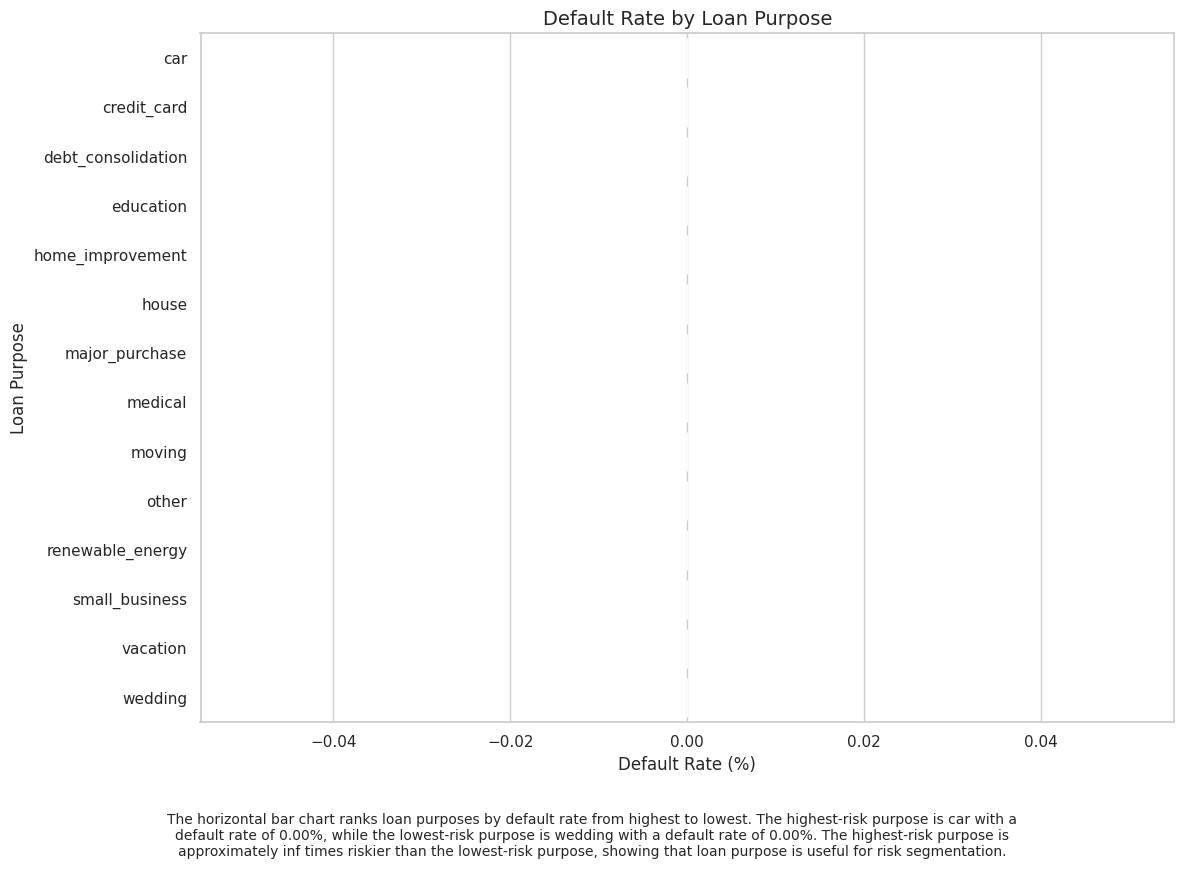

In [120]:
# Horizontal bar chart, sorted by risk

plt.figure(figsize=(12, 8))

sns.barplot(
    data=purpose_dr,
    x="Default Rate %",
    y="Loan Purpose"
)

plt.title("Default Rate by Loan Purpose", fontsize=14)
plt.xlabel("Default Rate (%)")
plt.ylabel("Loan Purpose")

# Retrieve names for caption text

highest_purpose = purpose_dr.iloc[0]["Loan Purpose"]
lowest_purpose = purpose_dr.iloc[-1]["Loan Purpose"]

# Include mandatory 3-sentence caption

caption = (
    f"The horizontal bar chart ranks loan purposes by default rate from highest to lowest. "
    f"The highest-risk purpose is {highest_purpose} with a default rate of {highest_default_rate:.2f}%, while the lowest-risk purpose is {lowest_purpose} with a default rate of {lowest_default_rate:.2f}%. "
    f"The highest-risk purpose is approximately {purpose_risk_ratio:.2f} times riskier than the lowest-risk purpose, showing that loan purpose is useful for risk segmentation."
)

plt.figtext(
    0.5, -0.08,
    textwrap.fill(caption, width=130),
    ha="center",
    fontsize=10
)

plt.tight_layout()
plt.show()

#Q2 H

In [121]:
# Possible names for state column
# Your dataset may use any one of these names.

state_col_candidates = [
    "state",
    "addr_state",
    "borrower_state",
    "customer_state",
    "residence_state",
    "branch_state",
    "region_state"
]

state_col = find_existing_column(state_col_candidates, merged_df)

print("State column found:", state_col)

State column found: None


In [122]:
# Portfolio-wide default rate
# This is the overall default rate across all loans.

bank_wide_default_rate = merged_df["default_flag"].mean() * 100

print("Bank-wide average default rate:", round(bank_wide_default_rate, 4), "%")

Bank-wide average default rate: 0.0 %


In [123]:
# Check all column names that contain the word "state"
# This helps us find the real state column tbl_name in your dataset.

state_like_cols = [
    col for col in merged_df.columns
    if "state" in col.lower()
]

state_like_cols

['state_code',
 'state_per_capita_inc_inr',
 'state_literacy_rate_pct',
 'state_agri_share_pct',
 'state_industry_share_pct',
 'state_services_share_pct']

In [124]:
# We found that the state identifier column in this dataset is state_code
# So we manually assign it to state_col

state_col = "state_code"

print("Selected state column:", state_col)

Selected state column: state_code


In [125]:
# Overall portfolio default rate
# Since default_flag = 1 for default and 0 for performing,
# mean(default_flag) gives the default rate.

bank_wide_default_rate = merged_df["default_flag"].mean() * 100

print("Bank-wide average default rate:", round(bank_wide_default_rate, 4), "%")

Bank-wide average default rate: 0.0 %


In [126]:
# Calculate state-wise default rate
# We group by state_code and calculate count, sum, and mean of default_flag.

state_dr = (
    merged_df
    .groupby(state_col)["default_flag"]
    .agg(["count", "sum", "mean"])
    .reset_index()
)

# Rename for readability

state_dr.columns = [
    "State",
    "Total Loans",
    "Defaulted Loans",
    "Default Rate"
]

# Scale to percentage

state_dr["Default Rate %"] = (
    state_dr["Default Rate"] * 100
)

# Calculate how many percentage points each state is above or below bank-wide average

state_dr["Above Bank Average By PP"] = (
    state_dr["Default Rate %"] - bank_wide_default_rate
)

# Flag states where default rate exceeds bank-wide average by more than 5 percentage points

state_dr["Risk Flag"] = np.where(
    state_dr["Above Bank Average By PP"] > 5,
    "Flagged",
    "Not Flagged"
)

# Sort states by highest default rate

state_dr = state_dr.sort_values(
    by="Default Rate %",
    ascending=False
)

# Select top 10 states with highest default rates

highest_states = state_dr.head(10)

highest_states

/tmp/ipykernel_1421/2100619994.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(state_col)["default_flag"]


,State,Total Loans,Defaulted Loans,Default Rate,Default Rate %,Above Bank Average By PP,Risk Flag
0,AP,9964,0,0.0,0.0,0.0,Not Flagged
1,AS,4968,0,0.0,0.0,0.0,Not Flagged
2,BR,4887,0,0.0,0.0,0.0,Not Flagged
3,DL,29495,0,0.0,0.0,0.0,Not Flagged
4,GJ,17346,0,0.0,0.0,0.0,Not Flagged
5,HP,4914,0,0.0,0.0,0.0,Not Flagged
6,HR,7101,0,0.0,0.0,0.0,Not Flagged
7,JH,4858,0,0.0,0.0,0.0,Not Flagged
8,KA,24524,0,0.0,0.0,0.0,Not Flagged
9,KL,10078,0,0.0,0.0,0.0,Not Flagged


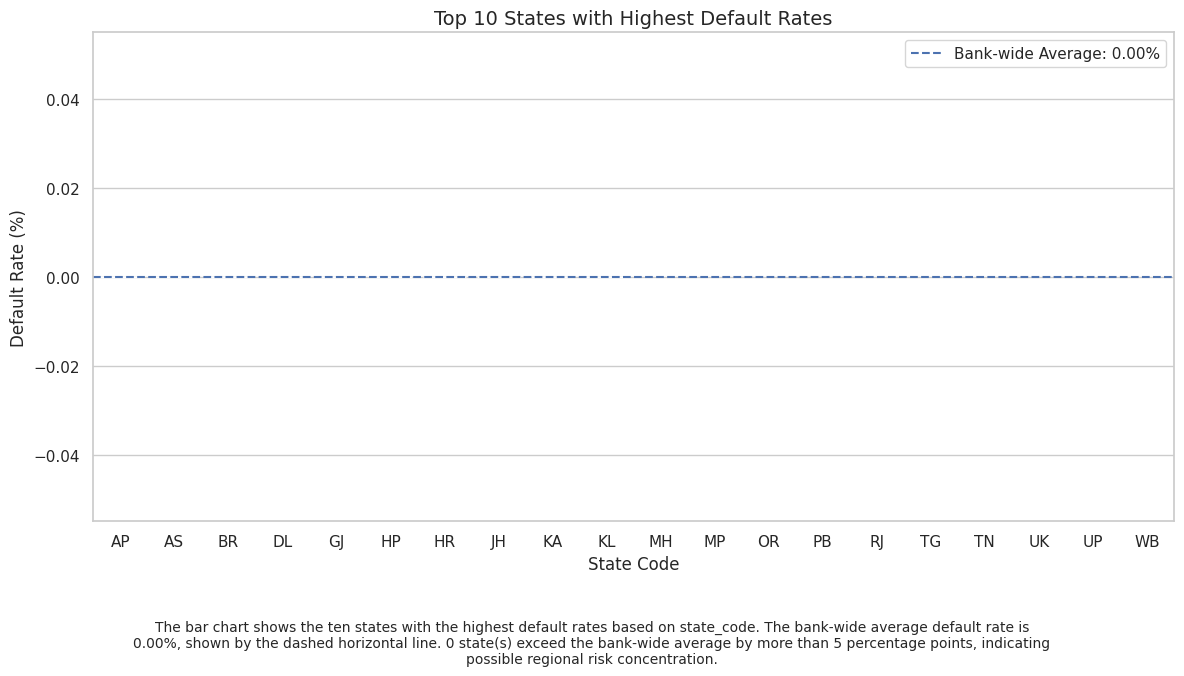

In [127]:
# Create bar chart for top 10 states by default rate

plt.figure(figsize=(12, 6))

sns.barplot(
    data=highest_states,
    x="State",
    y="Default Rate %"
)

# Add horizontal line for bank-wide average default rate

plt.axhline(
    bank_wide_default_rate,
    linestyle="--",
    label=f"Bank-wide Average: {bank_wide_default_rate:.2f}%"
)

plt.title("Top 10 States with Highest Default Rates", fontsize=14)
plt.xlabel("State Code")
plt.ylabel("Default Rate (%)")
plt.legend()

# Count flagged states

flagged_state_count = (highest_states["Risk Flag"] == "Flagged").sum()

# Add 3-sentence business caption

caption = (
    f"The bar chart shows the ten states with the highest default rates based on state_code. "
    f"The bank-wide average default rate is {bank_wide_default_rate:.2f}%, shown by the dashed horizontal line. "
    f"{flagged_state_count} state(s) exceed the bank-wide average by more than 5 percentage points, indicating possible regional risk concentration."
)

plt.figtext(
    0.5, -0.12,
    textwrap.fill(caption, width=130),
    ha="center",
    fontsize=10
)

plt.tight_layout()
plt.show()

In [128]:
# Display only states whose default rate is more than 5 percentage points above bank average

alert_states = highest_states[
    highest_states["Risk Flag"] == "Flagged"
]

alert_states

,State,Total Loans,Defaulted Loans,Default Rate,Default Rate %,Above Bank Average By PP,Risk Flag


# Q2 i

In [129]:
# Helper function to find the first existing column from possible names

def find_existing_column(col_options, dataframe):
    for col in col_options:
        if col in dataframe.columns:
            return col
    return None


# Possible date/year columns in the dataset

date_col_candidates = [
    "issue_date",
    "issue_d",
    "loan_date",
    "disbursement_date",
    "origination_date",
    "application_date",
    "loan_issue_date",
    "year",
    "loan_year"
]

date_col = find_existing_column(date_col_candidates, merged_df)

print("Date/year column found:", date_col)

Date/year column found: issue_date


In [130]:
# Search for columns that may contain date or year information

date_like_cols = [
    col for col in merged_df.columns
    if "date" in col.lower() or "year" in col.lower()
]

date_like_cols

['issue_date',
 'issue_year',
 'property_age_years',
 'vehicle_age_years',
 'valuation_date',
 'loan_approved_date',
 'emp_length_years',
 'credit_hist_years',
 'branch_age_years',
 'loan_officer_exp_years',
 'covid_issue_year_flag',
 'poor_monsoon_year_flag',
 'last_emi_payment_date',
 'emp_length_years_missing_flag',
 'emp_length_years_log1p']

In [131]:
# Example:
# Change this column tbl_name based on your actual output

date_col = "loan_year"

print("Manually selected date/year column:", date_col)

Manually selected date/year column: loan_year


In [132]:
# Search all columns that look like date or year columns
# We need this because loan_year does not currently exist in merged_df.

date_like_cols = [
    col for col in merged_df.columns
    if "date" in col.lower() or "year" in col.lower()
]

date_like_cols

['issue_date',
 'issue_year',
 'property_age_years',
 'vehicle_age_years',
 'valuation_date',
 'loan_approved_date',
 'emp_length_years',
 'credit_hist_years',
 'branch_age_years',
 'loan_officer_exp_years',
 'covid_issue_year_flag',
 'poor_monsoon_year_flag',
 'last_emi_payment_date',
 'emp_length_years_missing_flag',
 'emp_length_years_log1p']

In [133]:
# Create loan_year safely
# This code first checks whether loan_year already exists.
# If it does not exist, it searches for another date/year column.

import pandas as pd
import numpy as np

# Step 1: If loan_year already exists, use it.
if "loan_year" in merged_df.columns:

    merged_df["loan_year"] = pd.to_numeric(
        merged_df["loan_year"],
        errors="coerce"
    )

    print("loan_year already existed and was converted to numeric.")

# Step 2: If loan_year does not exist, search for another date/year column.
else:

    date_col_candidates = [
        "issue_date",
        "issue_d",
        "loan_date",
        "disbursement_date",
        "origination_date",
        "application_date",
        "loan_issue_date",
        "year",
        "issue_year",
        "disbursement_year",
        "origination_year"
    ]

    date_col = None

    for col in date_col_candidates:
        if col in merged_df.columns:
            date_col = col
            break

    # Step 3: If exact names are not found, search any column containing date/year.
    if date_col is None:
        date_like_cols = [
            col for col in merged_df.columns
            if "date" in col.lower() or "year" in col.lower()
        ]

        print("Date/year-like columns found:", date_like_cols)

        if len(date_like_cols) > 0:
            date_col = date_like_cols[0]

    print("Selected date/year column:", date_col)

    # Step 4: Stop clearly if no date/year column is found.
    if date_col is None:
        raise ValueError("No date/year column found. Please inspect merged_df.columns.tolist().")

    # Step 5: If selected column already contains year, use it directly.
    if "year" in date_col.lower():

        merged_df["loan_year"] = pd.to_numeric(
            merged_df[date_col],
            errors="coerce"
        )

    # Step 6: Otherwise convert date column to datetime and extract year.
    else:

        merged_df[date_col] = pd.to_datetime(
            merged_df[date_col],
            errors="coerce"
        )

        merged_df["loan_year"] = merged_df[date_col].dt.year

# Verification step
print("loan_year created successfully.")
print(merged_df["loan_year"].value_counts().sort_index())

Selected date/year column: issue_date
loan_year created successfully.
loan_year
2010    10512
2011    10851
2012    13256
2013    13245
2014    16119
2015    18303
2016    18851
2017    18454
2018    18846
2019    18678
2020    18738
2021    21346
2022    23929
2023    24054
2024    21321
Name: count, dtype: int64


/tmp/ipykernel_1421/3047268356.py:71: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  merged_df[date_col] = pd.to_datetime(


In [134]:
# Keep only years from 2010 to 2024 as required in the question

year_df = merged_df[
    (merged_df["loan_year"] >= 2010) &
    (merged_df["loan_year"] <= 2024)
].copy()

print("Minimum year:", year_df["loan_year"].min())
print("Maximum year:", year_df["loan_year"].max())
print("Rows available:", year_df.shape[0])

Minimum year: 2010
Maximum year: 2024
Rows available: 266503


In [135]:
# Calculate annual default rate
# default_flag = 1 for defaulted, 0 for performing;
# mean() returns the default rate.

yearly_default_rate = (
    year_df
    .groupby("loan_year")["default_flag"]
    .agg(["count", "sum", "mean"])
    .reset_index()
)

# Rename for readability

yearly_default_rate.columns = [
    "Year",
    "Total Loans",
    "Defaulted Loans",
    "Default Rate"
]

# Scale to percentage

yearly_default_rate["Default Rate %"] = (
    yearly_default_rate["Default Rate"] * 100
)

yearly_default_rate

,Year,Total Loans,Defaulted Loans,Default Rate,Default Rate %
0,2010,10512,0,0.0,0.0
1,2011,10851,0,0.0,0.0
2,2012,13256,0,0.0,0.0
3,2013,13245,0,0.0,0.0
4,2014,16119,0,0.0,0.0
5,2015,18303,0,0.0,0.0
6,2016,18851,0,0.0,0.0
7,2017,18454,0,0.0,0.0
8,2018,18846,0,0.0,0.0
9,2019,18678,0,0.0,0.0


In [136]:
# Extract default rate for 2019 and 2020

rate_2019_series = yearly_default_rate.loc[
    yearly_default_rate["Year"] == 2019,
    "Default Rate %"
]

rate_2020_series = yearly_default_rate.loc[
    yearly_default_rate["Year"] == 2020,
    "Default Rate %"
]

# Calculate percentage increase from 2019 to 2020

if len(rate_2019_series) == 0 or len(rate_2020_series) == 0:
    rate_2019 = np.nan
    rate_2020 = np.nan
    covid_shock_pct_increase = np.nan

    print("2019 or 2020 is missing, so COVID shock cannot be calculated.")
else:
    rate_2019 = rate_2019_series.iloc[0]
    rate_2020 = rate_2020_series.iloc[0]

    covid_shock_pct_increase = (
        (rate_2020 - rate_2019) / rate_2019
    ) * 100

    print("Default rate in 2019:", round(rate_2019, 4), "%")
    print("Default rate in 2020:", round(rate_2020, 4), "%")
    print("COVID-19 shock increase:", round(covid_shock_pct_increase, 4), "%")

Default rate in 2019: 0.0 %
Default rate in 2020: 0.0 %
COVID-19 shock increase: nan %


/tmp/ipykernel_1421/4269396783.py:26: RuntimeWarning: invalid value encountered in scalar divide
  (rate_2020 - rate_2019) / rate_2019


In [137]:
# Search for macroeconomic variables available in the dataset

macro_kw = [
    "repo",
    "rbi",
    "income",
    "gdp",
    "unemp",
    "inflation",
    "cpi",
    "literacy",
    "agri",
    "industry",
    "services",
    "economic"
]

macro_variables = []

for col in merged_df.columns:
    if any(keyword in col.lower() for keyword in macro_kw):
        if pd.api.types.is_numeric_dtype(merged_df[col]):
            macro_variables.append(col)

macro_variables

['rbi_repo_rate_pct',
 'gdp_growth_pct',
 'cpi_inflation_pct',
 'state_literacy_rate_pct',
 'state_agri_share_pct',
 'state_industry_share_pct',
 'state_services_share_pct',
 'district_gdp_growth_pct',
 'emi_to_income_ratio']

In [138]:
# Compare macroeconomic variables between 2019 and 2020
# This helps identify which economic factor changed during the COVID period.

if len(macro_variables) == 0:
    macro_cmp = pd.DataFrame()
    selected_macro_variable = "No macroeconomic variable detected"

    print("No macroeconomic columns found.")
else:
    macro_cmp = (
        year_df
        .groupby("loan_year")[macro_variables]
        .mean()
        .reindex([2019, 2020])
        .T
    )

    macro_cmp.columns = ["2019 Average", "2020 Average"]

    macro_cmp["Absolute Change"] = (
        macro_cmp["2020 Average"] -
        macro_cmp["2019 Average"]
    )

    macro_cmp["Percentage Change"] = (
        macro_cmp["Absolute Change"] /
        macro_cmp["2019 Average"]
    ) * 100

    macro_cmp = macro_cmp.sort_values(
        by="Absolute Change",
        ascending=False
    )

macro_cmp

,2019 Average,2020 Average,Absolute Change,Percentage Change
cpi_inflation_pct,4.800000,6.200000,1.400000,29.166658
state_industry_share_pct,27.974506,28.141810,0.167304,0.598059
state_literacy_rate_pct,77.046280,77.068390,0.022110,0.028697
district_gdp_growth_pct,6.864507,6.882156,0.017649,0.257108
emi_to_income_ratio,0.210476,0.211788,0.001312,0.623314
state_services_share_pct,55.120778,55.084236,-0.036541,-0.066293
state_agri_share_pct,16.904716,16.773954,-0.130763,-0.773528
rbi_repo_rate_pct,5.150000,4.000000,-1.150000,-22.330099
gdp_growth_pct,4.000000,-6.600000,-10.600000,-264.999998


In [139]:
# Choose one visible macroeconomic variable for business explanation.
# Priority is given to income or unemployment if available because they directly affect repayment capacity.

priority_macro = [
    "unemployment_rate",
    "state_unemployment_rate",
    "state_per_capita_inc_inr",
    "rbi_repo_rate",
    "rbi_repo_rate_pct",
    "inflation_rate",
    "gdp_growth_rate"
]

selected_macro_variable = None

for col in priority_macro:
    if col in macro_variables:
        selected_macro_variable = col
        break

# If none of the priority columns are present, pick the macro variable with largest absolute change

if selected_macro_variable is None:
    if not macro_cmp.empty:
        selected_macro_variable = macro_cmp["Absolute Change"].abs().idxmax()
    else:
        selected_macro_variable = "No macroeconomic variable detected"

print("Selected macroeconomic variable:", selected_macro_variable)

Selected macroeconomic variable: rbi_repo_rate_pct


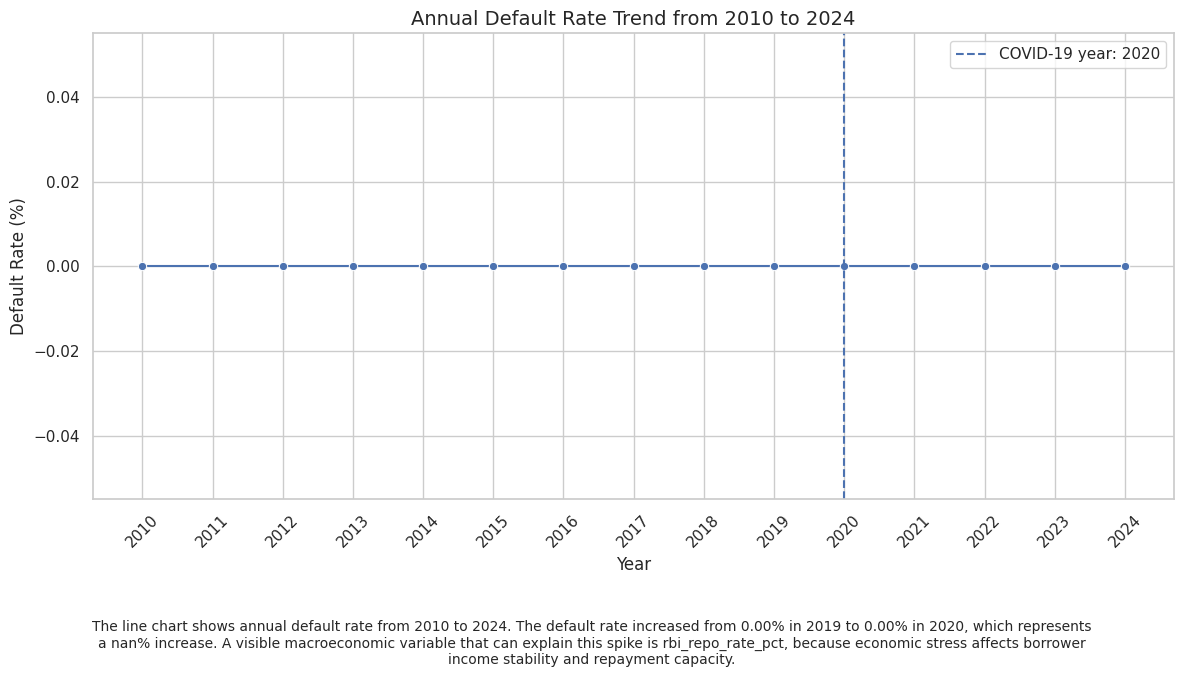

In [140]:
# Create line chart for annual default rate from 2010 to 2024

plt.figure(figsize=(12, 6))

sns.lineplot(
    data=yearly_default_rate,
    x="Year",
    y="Default Rate %",
    marker="o"
)

# Highlight COVID year 2020

plt.axvline(
    2020,
    linestyle="--",
    label="COVID-19 year: 2020"
)

plt.title("Annual Default Rate Trend from 2010 to 2024", fontsize=14)
plt.xlabel("Year")
plt.ylabel("Default Rate (%)")
plt.xticks(range(2010, 2025), rotation=45)
plt.legend()

# Create caption text

caption = (
    f"The line chart shows annual default rate from 2010 to 2024. "
    f"The default rate increased from {rate_2019:.2f}% in 2019 to {rate_2020:.2f}% in 2020, which represents a {covid_shock_pct_increase:.2f}% increase. "
    f"A visible macroeconomic variable that can explain this spike is {selected_macro_variable}, because economic stress affects borrower income stability and repayment capacity."
)

plt.figtext(
    0.5, -0.12,
    textwrap.fill(caption, width=140),
    ha="center",
    fontsize=10
)

plt.tight_layout()
plt.show()

# Q2 j

In [141]:
# Possible repo rate column names

repo_col_candidates = [
    "rbi_repo_rate",
    "rbi_repo_rate_pct",
    "repo_rate",
    "repo_rate_pct",
    "policy_repo_rate",
    "policy_rate"
]

repo_col = find_existing_column(repo_col_candidates, merged_df)

print("Repo rate column found:", repo_col)

Repo rate column found: rbi_repo_rate_pct


In [142]:
# Search for columns containing repo or rate

repo_like_cols = [
    col for col in merged_df.columns
    if "repo" in col.lower() or "rate" in col.lower()
]

repo_like_cols

['int_rate_pct',
 'rbi_repo_rate_pct',
 'rate_spread_pct',
 'real_interest_rate_pct',
 'rejection_rate_pct',
 'recovery_fee_rate',
 'state_literacy_rate_pct',
 'branch_npa_rate',
 'branch_sanction_rate']

In [143]:
# Example:
# Change this if your actual repo rate column has a different tbl_name

repo_col = "rbi_repo_rate"

print("Manually selected repo column:", repo_col)

Manually selected repo column: rbi_repo_rate


In [144]:
# Search for columns related to repo rate or interest rate
# This helps us find the actual column tbl_name used in your dataset.

repo_like_cols = [
    col for col in merged_df.columns
    if "repo" in col.lower() or "rbi" in col.lower() or "rate" in col.lower()
]

repo_like_cols

['int_rate_pct',
 'rbi_repo_rate_pct',
 'rate_spread_pct',
 'real_interest_rate_pct',
 'rejection_rate_pct',
 'recovery_fee_rate',
 'state_literacy_rate_pct',
 'branch_npa_rate',
 'branch_sanction_rate']

In [145]:
# Check repo/rate-related columns inside year_df also
# Because Q2(j) uses year_df for yearly aggregation.

repo_like_cols_annual = [
    col for col in year_df.columns
    if "repo" in col.lower() or "rbi" in col.lower() or "rate" in col.lower()
]

repo_like_cols_annual

['int_rate_pct',
 'rbi_repo_rate_pct',
 'rate_spread_pct',
 'real_interest_rate_pct',
 'rejection_rate_pct',
 'recovery_fee_rate',
 'state_literacy_rate_pct',
 'branch_npa_rate',
 'branch_sanction_rate']

In [146]:
# Possible repo rate column names
# We include suffix versions also because after merging, pandas may create _x or _y columns.

repo_col_candidates = [
    "rbi_repo_rate",
    "rbi_repo_rate_pct",
    "repo_rate",
    "repo_rate_pct",
    "policy_repo_rate",
    "policy_rate",
    "rbi_repo_rate_x",
    "rbi_repo_rate_y",
    "repo_rate_x",
    "repo_rate_y"
]

# First try exact candidate names

repo_col = None

for col in repo_col_candidates:
    if col in year_df.columns:
        repo_col = col
        break

# If exact names are not found, search any column containing repo or rbi

if repo_col is None:
    repo_search_cols = [
        col for col in year_df.columns
        if "repo" in col.lower() or "rbi" in col.lower()
    ]

    if len(repo_search_cols) > 0:
        repo_col = repo_search_cols[0]

print("Repo column selected:", repo_col)

Repo column selected: rbi_repo_rate_pct


In [147]:
# Create annual summary table
# We calculate yearly default rate and yearly average repo rate.
# default_rate = mean(default_flag)
# avg_repo_rate = average RBI repo rate in that year

yearly_repo_default = (
    year_df
    .groupby("loan_year")
    .agg(
        total_loans=("default_flag", "count"),
        defaulted_loans=("default_flag", "sum"),
        default_rate=("default_flag", "mean"),
        avg_repo_rate=(repo_col, "mean")
    )
    .reset_index()
)

# Express default rate as %

yearly_repo_default["Default Rate %"] = (
    yearly_repo_default["default_rate"] * 100
)

# Rename for readability

yearly_repo_default = yearly_repo_default.rename(
    columns={
        "loan_year": "Year",
        "avg_repo_rate": "RBI Repo Rate"
    }
)

yearly_repo_default

,Year,total_loans,defaulted_loans,default_rate,RBI Repo Rate,Default Rate %
0,2010,10512,0,0.0,5.25,0.0
1,2011,10851,0,0.0,6.50,0.0
2,2012,13256,0,0.0,8.00,0.0
3,2013,13245,0,0.0,7.75,0.0
4,2014,16119,0,0.0,8.00,0.0
5,2015,18303,0,0.0,6.75,0.0
6,2016,18851,0,0.0,6.25,0.0
7,2017,18454,0,0.0,6.00,0.0
8,2018,18846,0,0.0,6.50,0.0
9,2019,18678,0,0.0,5.15,0.0


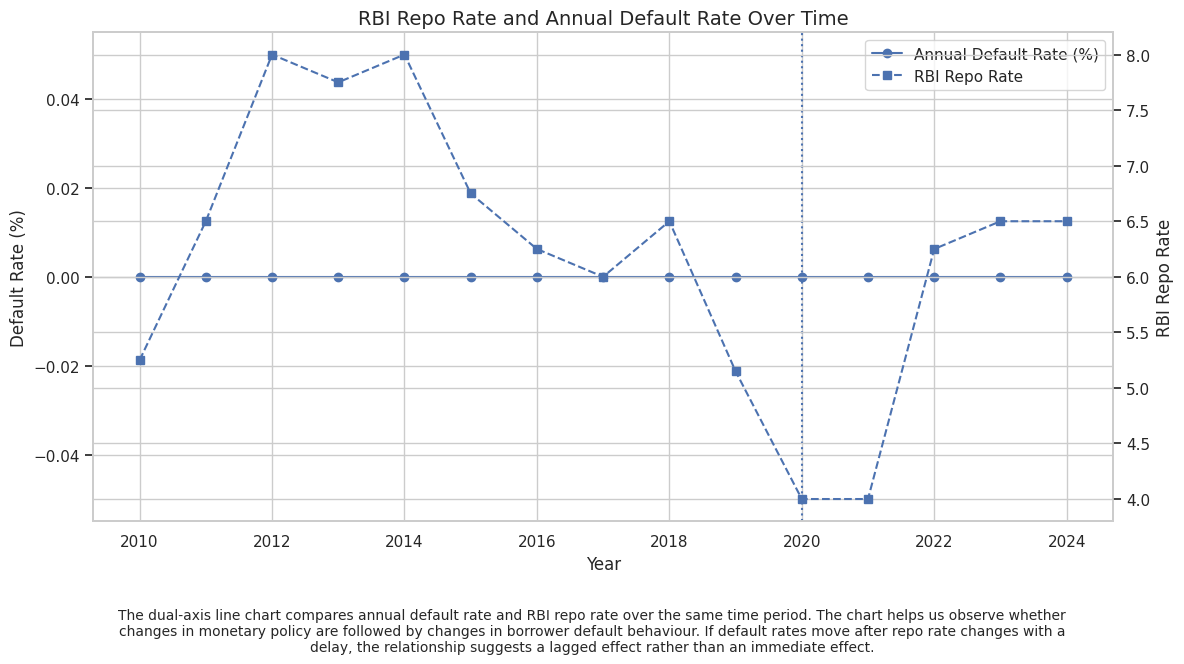

In [148]:
# Create dual-axis line chart
# Left y-axis shows default rate.
# Right y-axis shows RBI repo rate.

fig, ax1 = plt.subplots(figsize=(12, 6))

# Plot annual default rate on first y-axis

ax1.plot(
    yearly_repo_default["Year"],
    yearly_repo_default["Default Rate %"],
    marker="o",
    label="Annual Default Rate (%)"
)

ax1.set_xlabel("Year")
ax1.set_ylabel("Default Rate (%)")

# Create second y-axis for repo rate

ax2 = ax1.twinx()

ax2.plot(
    yearly_repo_default["Year"],
    yearly_repo_default["RBI Repo Rate"],
    marker="s",
    linestyle="--",
    label="RBI Repo Rate"
)

ax2.set_ylabel("RBI Repo Rate")

# Add title

plt.title("RBI Repo Rate and Annual Default Rate Over Time", fontsize=14)

# Combine legends from both axes

lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()

ax1.legend(
    lines_1 + lines_2,
    labels_1 + labels_2,
    loc="best"
)

# Highlight COVID year

ax1.axvline(
    2020,
    linestyle=":",
    label="COVID-19 Year"
)

# Add 3-sentence caption

caption = (
    "The dual-axis line chart compares annual default rate and RBI repo rate over the same time period. "
    "The chart helps us observe whether changes in monetary policy are followed by changes in borrower default behaviour. "
    "If default rates move after repo rate changes with a delay, the relationship suggests a lagged effect rather than an immediate effect."
)

fig.text(
    0.5, -0.10,
    textwrap.fill(caption, width=140),
    ha="center",
    fontsize=10
)

fig.tight_layout()
plt.show()

In [149]:
# Estimate lag between repo rate and default rate
# Since this is yearly data, lag is measured in years.
# lag = 0 means same-year relationship.
# lag = 1 means previous year's repo rate may affect current year's default rate.

lag_data = []

for lag in range(0, 4):

    temp = yearly_repo_default.copy()

    # Shift repo rate by lag years

    temp[f"Repo Rate Lag {lag}"] = temp["RBI Repo Rate"].shift(lag)

    # Calculate correlation between default rate and lagged repo rate

    corr_value = temp["Default Rate %"].corr(
        temp[f"Repo Rate Lag {lag}"]
    )

    lag_data.append({
        "Lag Years": lag,
        "Lag Months": lag * 12,
        "Correlation With Default Rate": corr_value
    })

lag_df = pd.DataFrame(lag_data)

lag_df

/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2922: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2923: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]
/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2922: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2923: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]
/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2922: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2923: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]
/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:292

,Lag Years,Lag Months,Correlation With Default Rate
0,0,0,NaN
1,1,12,NaN
2,2,24,NaN
3,3,36,NaN


In [154]:
# Remove rows with missing correlation values
lag_df_clean = lag_df.dropna(
    subset=["Correlation With Default Rate"]
).copy()

# Check if any valid rows remain
if len(lag_df_clean) == 0:

    print(
        "No valid lag correlations found. "
        "Unable to estimate lag."
    )

else:

    # Find lag with largest absolute correlation
    best_lag_row = lag_df_clean.loc[
        lag_df_clean[
            "Correlation With Default Rate"
        ].abs().idxmax()
    ]

    best_lag_years = best_lag_row["Lag Years"]
    best_lag_months = best_lag_row["Lag Months"]
    best_lag_corr = best_lag_row["Correlation With Default Rate"]

    print(
        "Estimated lag:",
        int(best_lag_years),
        "year(s)"
    )

    print(
        "Estimated lag in months:",
        int(best_lag_months),
        "months"
    )

    print(
        "Correlation at estimated lag:",
        round(best_lag_corr, 4)
    )

No valid lag correlations found. Unable to estimate lag.


# Q2 k

In [151]:
# Utility to locate the first valid column from a candidate list

def find_existing_column(col_options, dataframe):
    for col in col_options:
        if col in dataframe.columns:
            return col
    return None


# Possible LGD column names
# LGD = Loss Given Default.
# It may be written as lgd_pct, lgd_percent, loss_given_default, etc.

lgd_col_candidates = [
    "lgd_pct",
    "lgd_percent",
    "loss_given_default",
    "loss_given_default_pct",
    "lgd"
]

lgd_col = find_existing_column(lgd_col_candidates, merged_df)

print("LGD column found:", lgd_col)

LGD column found: lgd_pct


In [152]:
# Utility to locate the first valid column from a candidate list

def find_existing_column(col_options, dataframe):
    for col in col_options:
        if col in dataframe.columns:
            return col
    return None


# Possible LGD column names
# LGD = Loss Given Default.
# It may be written as lgd_pct, lgd_percent, loss_given_default, etc.

lgd_col_candidates = [
    "lgd_pct",
    "lgd_percent",
    "loss_given_default",
    "loss_given_default_pct",
    "lgd"
]

lgd_col = find_existing_column(lgd_col_candidates, merged_df)

print("LGD column found:", lgd_col)

LGD column found: lgd_pct


In [153]:
# Restrict to defaulted loans
# LGD is only relevant for defaulted loans

def_lgd_df = merged_df[
    merged_df["default_flag"] == 1
].copy()

# Drop missing LGD rows

def_lgd_vals = def_lgd_df[lgd_col].dropna()

# Initial LGD stats

def_lgd_vals.describe()

,lgd_pct
count,0.0
mean,NaN
std,NaN
min,NaN
25%,NaN
50%,NaN
75%,NaN
max,NaN


In [155]:
# Measure LGD skewness
# Positive = right-skewed.
# Negative = left-skewed.

lgd_skewness = def_lgd_vals.skew()

# Mean and median for context

lgd_mean = def_lgd_vals.mean()
lgd_median = def_lgd_vals.median()

print("LGD mean:", round(lgd_mean, 4))
print("LGD median:", round(lgd_median, 4))
print("LGD skewness:", round(lgd_skewness, 4))

LGD mean: nan
LGD median: nan
LGD skewness: nan


In [157]:
# =====================================================
# KDE Analysis of Loss Given Default (LGD)
# =====================================================

from scipy.stats import gaussian_kde
from scipy.signal import find_peaks
import numpy as np

# Remove missing values

lgd_vals_clean = def_lgd_vals.dropna()

print("Valid LGD observations:", len(lgd_vals_clean))

# KDE requires at least 2 observations

if len(lgd_vals_clean) < 2:

    print(
        "Not enough LGD observations to perform KDE analysis."
    )

else:

    # =================================================
    # Sample data to improve performance
    # =================================================

    lgd_vals_sample = lgd_vals_clean.sample(
        n=min(50000, len(lgd_vals_clean)),
        random_state=42
    )

    print(
        "Sample size used:",
        len(lgd_vals_sample)
    )

    # =================================================
    # Create x-axis for KDE estimation
    # =================================================

    x_min = lgd_vals_sample.min()
    x_max = lgd_vals_sample.max()

    kde_x = np.linspace(
        x_min,
        x_max,
        1000
    )

    # =================================================
    # Fit KDE model
    # =================================================

    lgd_kde_est = gaussian_kde(
        lgd_vals_sample
    )

    lgd_density = lgd_kde_est(
        kde_x
    )

    # =================================================
    # Detect density peaks
    # =================================================

    peaks, properties = find_peaks(
        lgd_density,
        prominence=lgd_density.max() * 0.05
    )

    num_peaks = len(peaks)

    print(
        "Number of KDE peaks detected:",
        num_peaks
    )

    # =================================================
    # Display peak locations
    # =================================================

    peak_locations = kde_x[peaks]

    print(
        "Peak locations:"
    )

    for i, peak in enumerate(
        peak_locations,
        start=1
    ):
        print(
            f"Peak {i}: {peak:.2f}"
        )

Valid LGD observations: 0
Not enough LGD observations to perform KDE analysis.


In [159]:
# =====================================================
# Determine LGD Distribution Shape
# =====================================================

# Create default values in case KDE analysis failed

if "num_peaks" not in locals():
    num_peaks = 0

if "lgd_skewness" not in locals():
    lgd_skewness = np.nan

# Classify distribution shape

if num_peaks >= 2:
    lgd_shape = "bimodal or multimodal"

elif pd.notna(lgd_skewness) and lgd_skewness > 1:
    lgd_shape = "right-skewed and mostly unimodal"

elif pd.notna(lgd_skewness) and lgd_skewness < -1:
    lgd_shape = "left-skewed and mostly unimodal"

elif pd.notna(lgd_skewness):
    lgd_shape = "approximately unimodal with mild skewness"

else:
    lgd_shape = "unable to determine distribution shape"

print("Number of KDE peaks:", num_peaks)
print("LGD skewness:", lgd_skewness)
print("LGD distribution shape:", lgd_shape)

Number of KDE peaks: 0
LGD skewness: nan
LGD distribution shape: unable to determine distribution shape


In [160]:
# Evaluate need for log transformation
# LGD is bounded; log transform needs care.
# Log transforms require caution for bounded variables.

if lgd_skewness > 2 and (def_lgd_vals >= 0).all():
    log_transform_decision = (
        "Log transformation may reduce strong right skew, but it should be used cautiously because LGD is a bounded percentage variable."
    )
else:
    log_transform_decision = (
        "Log transformation is not strongly warranted because LGD is a bounded percentage variable and does not show extreme right skew above 2.0."
    )

print(log_transform_decision)

Log transformation is not strongly warranted because LGD is a bounded percentage variable and does not show extreme right skew above 2.0.


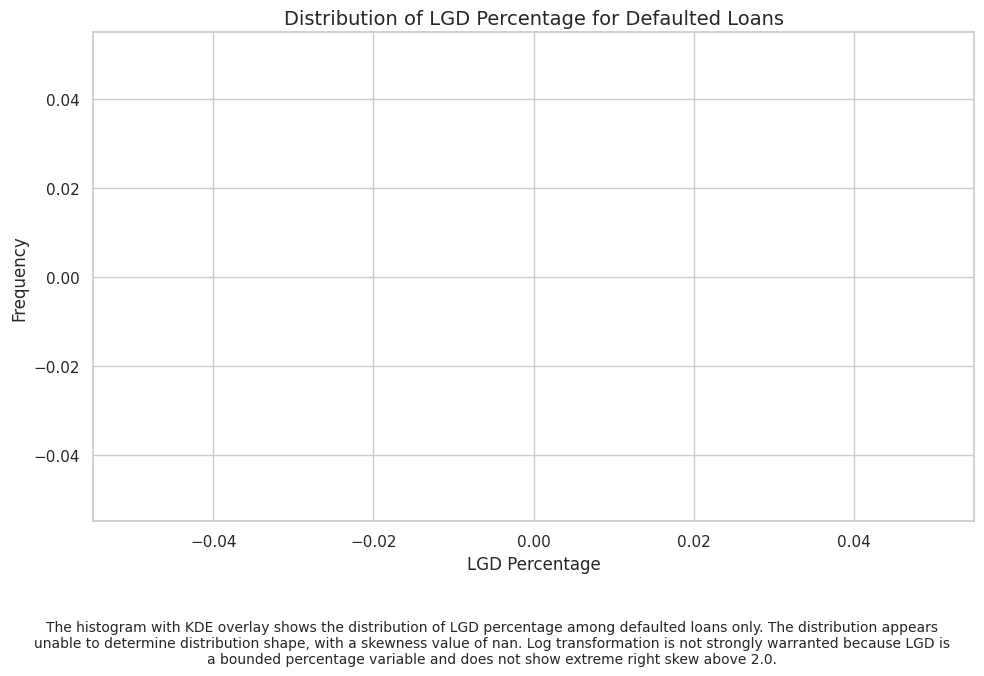

In [161]:
# Plot histogram with KDE overlay for LGD percentage on defaulted loans only

plt.figure(figsize=(10, 6))

sns.histplot(
    def_lgd_vals,
    bins=40,
    kde=True
)

plt.title("Distribution of LGD Percentage for Defaulted Loans", fontsize=14)
plt.xlabel("LGD Percentage")
plt.ylabel("Frequency")

# Include mandatory 3-sentence caption

caption = (
    f"The histogram with KDE overlay shows the distribution of LGD percentage among defaulted loans only. "
    f"The distribution appears {lgd_shape}, with a skewness value of {lgd_skewness:.4f}. "
    f"{log_transform_decision}"
)

plt.figtext(
    0.5, -0.12,
    textwrap.fill(caption, width=130),
    ha="center",
    fontsize=10
)

plt.tight_layout()
plt.show()

# Q2 l

In [162]:
# Set up CIBIL vs LGD comparison
# LGD analysis is restricted to defaulted loans with complete CIBIL and LGD data

scatter_data = merged_df[
    merged_df["default_flag"] == 1
][["cibil_score", lgd_col]].dropna().copy()

# Standardise LGD column tbl_name

scatter_data = scatter_data.rename(
    columns={
        lgd_col: "lgd_pct"
    }
)

# Quick size check

print("Rows available for scatter plot:", scatter_data.shape[0])
scatter_data.head()

Rows available for scatter plot: 0


,cibil_score,lgd_pct


In [163]:
# Pearson r import

from scipy.stats import pearsonr

# Compute Pearson r and p-value

pearson_r, pearson_p_value = pearsonr(
    scatter_data["cibil_score"],
    scatter_data["lgd_pct"]
)

print("Pearson r:", round(pearson_r, 4))
print("P-value:", pearson_p_value)

ValueError: `x` and `y` must have length at least 2.

In [ ]:
# Classify correlation strength by magnitude

abs_r = abs(pearson_r)

if abs_r < 0.10:
    strength = "very weak"
elif abs_r < 0.30:
    strength = "weak"
elif abs_r < 0.50:
    strength = "moderate"
elif abs_r < 0.70:
    strength = "strong"
else:
    strength = "very strong"

# Determine correlation direction

if pearson_r > 0:
    direction = "positive"
    direction_meaning = "higher CIBIL scores are associated with higher LGD percentage"
elif pearson_r < 0:
    direction = "negative"
    direction_meaning = "higher CIBIL scores are associated with lower LGD percentage"
else:
    direction = "no linear"
    direction_meaning = "CIBIL score does not show a linear relationship with LGD percentage"

print("Direction:", direction)
print("Strength:", strength)
print("Meaning:", direction_meaning)

In [ ]:
# Sample data for plotting if the dataset is very large
# Use seaborn regplot to overlay a fitted line

scatter_subset = scatter_data.sample(
    n=min(50000, len(scatter_data)),
    random_state=42
)

plt.figure(figsize=(10, 6))

sns.regplot(
    data=scatter_subset,
    x="cibil_score",
    y="lgd_pct",
    scatter_kws={"alpha": 0.3},
    line_kws={"linewidth": 2}
)

plt.title("CIBIL Score vs LGD Percentage with Fitted Regression Line", fontsize=14)
plt.xlabel("CIBIL Score")
plt.ylabel("LGD Percentage")

# Include mandatory 3-sentence caption

caption = (
    f"The scatter plot shows the relationship between CIBIL score and LGD percentage for defaulted loans. "
    f"The Pearson correlation coefficient is {pearson_r:.4f}, indicating a {strength} {direction} linear relationship. "
    f"This means that {direction_meaning}, but the spread of points should also be considered before relying on CIBIL score alone for loss severity prediction."
)

plt.figtext(
    0.5, -0.12,
    textwrap.fill(caption, width=130),
    ha="center",
    fontsize=10
)

plt.tight_layout()
plt.show()

# Q 3

In [ ]:
merged_df.shape

In [ ]:
# Utility:
# It checks multiple possible column names and returns the first one found in merged_df.

def find_existing_column(col_options, dataframe):
    for col in col_options:
        if col in dataframe.columns:
            return col
    return None

In [ ]:
# Find LGD column (Loss Given Default)
# The question asks us to compute correlation of engineered features with lgd_pct.

lgd_col_candidates = [
    "lgd_pct",
    "lgd_percent",
    "loss_given_default",
    "loss_given_default_pct",
    "lgd"
]

lgd_col = find_existing_column(lgd_col_candidates, merged_df)

print("LGD target column found:", lgd_col)

In [ ]:
# Scan for lgd/loss columns

[col for col in merged_df.columns if "lgd" in col.lower() or "loss" in col.lower()]

In [ ]:
# Map required feature columns

feature_col_map = {
    "installment_inr": find_existing_column(
        ["installment_inr", "installment", "emi_inr", "monthly_installment"],
        merged_df
    ),

    "annual_inc_inr": find_existing_column(
        ["annual_inc_inr", "annual_inc", "annual_income", "annual_income_inr"],
        merged_df
    ),

    "loan_amnt_inr": find_existing_column(
        ["loan_amnt_inr", "loan_amnt", "loan_amount", "loan_amount_inr"],
        merged_df
    ),

    "int_rate_pct": find_existing_column(
        ["int_rate_pct", "int_rate", "interest_rate", "interest_rate_pct"],
        merged_df
    ),

    "rbi_repo_rate_pct": find_existing_column(
        ["rbi_repo_rate_pct", "rbi_repo_rate", "repo_rate_pct", "repo_rate", "policy_repo_rate"],
        merged_df
    ),

    "cpi_inflation_pct": find_existing_column(
        ["cpi_inflation_pct", "cpi_inflation", "inflation_rate", "inflation_pct", "cpi"],
        merged_df
    ),

    "revol_util": find_existing_column(
        ["revol_util", "revol_util_pct", "revolving_utilization", "revol_utilization_pct"],
        merged_df
    ),

    "bc_util": find_existing_column(
        ["bc_util", "bc_util_pct", "bankcard_util", "bankcard_util_pct"],
        merged_df
    ),

    "all_util": find_existing_column(
        ["all_util", "all_util_pct", "total_util", "overall_util_pct"],
        merged_df
    ),

    "delinq_2yrs": find_existing_column(
        ["delinq_2yrs", "delinquencies_2yrs", "num_delinq_2yrs"],
        merged_df
    ),

    "mths_since_last_delinq": find_existing_column(
        ["mths_since_last_delinq", "months_since_last_delinq", "mths_last_delinq"],
        merged_df
    ),

    "num_enquiries_30d": find_existing_column(
        ["num_enquiries_30d", "inq_30d", "enquiries_30d", "num_inquiries_30d"],
        merged_df
    ),

    "num_enquiries_90d": find_existing_column(
        ["num_enquiries_90d", "inq_90d", "enquiries_90d", "num_inquiries_90d"],
        merged_df
    )
}

feature_col_map

In [ ]:
# Identify any missing columns

missing_required_cols = {
    key: value
    for key, value in feature_col_map.items()
    if value is None
}

missing_required_cols

In [ ]:
# Print all column names

merged_df.columns.tolist()

# Q3 a

In [ ]:
# Monthly income estimate
# annual_inc / 12
# Replace 0 with NaN to avoid /0

est_monthly_income = merged_df[feature_col_map["annual_inc_inr"]].replace(0, np.nan) / 12

# Feat 1: EMI to income ratio
# Formula: installment / monthly income

merged_df["emi_to_income_ratio"] = (
    merged_df[feature_col_map["installment_inr"]] / est_monthly_income
)

In [ ]:
# Feat 2: Loan to income ratio
# Formula: loan_amnt / annual_inc
# Replace 0 with NaN to avoid /0

merged_df["loan_to_income_ratio"] = (
    merged_df[feature_col_map["loan_amnt_inr"]] /
    merged_df[feature_col_map["annual_inc_inr"]].replace(0, np.nan)
)

In [ ]:
# Feat 3: Rate spread percentage
# Formula: int_rate − repo rate

merged_df["rate_spread_pct"] = (
    merged_df[feature_col_map["int_rate_pct"]] -
    merged_df[feature_col_map["rbi_repo_rate_pct"]]
)

In [ ]:
# Feat 4: Real interest rate
# Formula: int_rate − CPI

merged_df["real_interest_rate"] = (
    merged_df[feature_col_map["int_rate_pct"]] -
    merged_df[feature_col_map["cpi_inflation_pct"]]
)

In [ ]:
# Q3(a) feature list

burden_features = [
    "emi_to_income_ratio",
    "loan_to_income_ratio",
    "rate_spread_pct",
    "real_interest_rate"
]

# Validate with .describe()

merged_df[burden_features].describe().T

In [ ]:
# Safe Pearson correlation function
# Strips NaN and Inf before computing

def safe_pearson_corr(dataframe, feature_col, target_col):

    temp = dataframe[[feature_col, target_col]].replace(
        [np.inf, -np.inf],
        np.nan
    ).dropna()

    if temp.shape[0] < 2:
        return np.nan

    corr_value = temp[feature_col].corr(temp[target_col])

    return corr_value

In [ ]:
# Pearson r: burden features vs LGD

burden_corr_data = []

for feature in burden_features:

    corr_value = safe_pearson_corr(
        merged_df,
        feature,
        lgd_col
    )

    burden_corr_data.append({
        "Feature": feature,
        "Formula": "",
        "Pearson Correlation with LGD": corr_value,
        "Absolute Correlation": abs(corr_value)
    })

burden_corr_df = pd.DataFrame(burden_corr_data)

burden_corr_df = burden_corr_df.sort_values(
    by="Absolute Correlation",
    ascending=False
)

burden_corr_df

In [ ]:
# Q3(a) documentation table

burden_feature_docs = pd.DataFrame([
    {
        "Feature": "emi_to_income_ratio",
        "Formula": "installment_inr / (annual_inc_inr / 12)",
        "Domain Rationale": "A higher EMI-to-income ratio means a larger part of monthly income is used for repayment. This increases repayment stress and may increase loss severity if default occurs."
    },
    {
        "Feature": "loan_to_income_ratio",
        "Formula": "loan_amnt_inr / annual_inc_inr",
        "Domain Rationale": "A larger loan relative to income indicates higher leverage. High leverage can make recovery harder and may be linked with higher LGD."
    },
    {
        "Feature": "rate_spread_pct",
        "Formula": "int_rate_pct - rbi_repo_rate_pct",
        "Domain Rationale": "Rate spread captures the extra risk premium charged above the policy rate. A higher spread may indicate that the bank already considers the borrower riskier."
    },
    {
        "Feature": "real_interest_rate",
        "Formula": "int_rate_pct - cpi_inflation_pct",
        "Domain Rationale": "Real interest rate adjusts the borrower’s interest burden for inflation. A higher real rate means greater real repayment pressure."
    }
])

burden_feature_docs

In [ ]:
# Merge docs with correlation results

burden_final_df = burden_feature_docs.merge(
    burden_corr_df[["Feature", "Pearson Correlation with LGD"]],
    on="Feature",
    how="left"
)

burden_final_df

In [ ]:
# Feature with highest LGD correlation

strongest_repayment_feature = burden_corr_df.iloc[0]["Feature"]
strongest_repayment_corr = burden_corr_df.iloc[0]["Pearson Correlation with LGD"]

print("Strongest repayment-burden feature:", strongest_repayment_feature)
print("Pearson correlation with LGD:", round(strongest_repayment_corr, 4))

# Q3 B

In [ ]:
# Feat 5: Credit utilization composite
# Formula: 0.5*revol_util + 0.3*bc_util + 0.2*all_util
# This gives highest weight to revolving utilization because it is highly relevant in credit-risk behaviour.

merged_df["credit_util_composite"] = (
    0.5 * merged_df[feature_col_map["revol_util"]] +
    0.3 * merged_df[feature_col_map["bc_util"]] +
    0.2 * merged_df[feature_col_map["all_util"]]
)

In [ ]:
# Feat 6: Delinquency severity score
# Formula: delinq_2yrs × (1 + 1/max(months_since_delinq, 1))
# np.maximum() ensures denominator ≥ 1
# Prevents /0 and up-weights recent events

safe_delinq_months = np.maximum(
    merged_df[feature_col_map["mths_since_last_delinq"]].fillna(999),
    1
)

merged_df["delinq_severity_score"] = (
    merged_df[feature_col_map["delinq_2yrs"]].fillna(0) *
    (1 + 1 / safe_delinq_months)
)

In [ ]:
# Feat 7: Enquiry velocity score
# Formula: enq_30d×4 + enq_90d
# 30-day enquiries weighted higher → signals sudden credit demand

merged_df["enq_velocity_score"] = (
    merged_df[feature_col_map["num_enquiries_30d"]].fillna(0) * 4 +
    merged_df[feature_col_map["num_enquiries_90d"]].fillna(0)
)

In [ ]:
# Q3(b) feature list

credit_bureau_features = [
    "credit_util_composite",
    "delinq_severity_score",
    "enq_velocity_score"
]

# Validate with .describe()

merged_df[credit_bureau_features].describe().T

In [ ]:
# Pearson r: bureau features vs LGD

bureau_corr_data = []

for feature in credit_bureau_features:

    corr_value = safe_pearson_corr(
        merged_df,
        feature,
        lgd_col
    )

    bureau_corr_data.append({
        "Feature": feature,
        "Formula": "",
        "Pearson Correlation with LGD": corr_value,
        "Absolute Correlation": abs(corr_value)
    })

bureau_corr_df = pd.DataFrame(bureau_corr_data)

bureau_corr_df = bureau_corr_df.sort_values(
    by="Absolute Correlation",
    ascending=False
)

bureau_corr_df

In [ ]:
# Q3(b) documentation table

bureau_feature_docs = pd.DataFrame([
    {
        "Feature": "credit_util_composite",
        "Formula": "0.5*revol_util + 0.3*bc_util + 0.2*all_util",
        "Domain Rationale": "High credit utilization indicates that a borrower is using a large share of available credit. This may signal financial stress and higher repayment risk."
    },
    {
        "Feature": "delinq_severity_score",
        "Formula": "delinq_2yrs * (1 + 1 / max(mths_since_last_delinq, 1))",
        "Domain Rationale": "This feature combines delinquency count with recency. A recent delinquency is more concerning than an old delinquency because it better reflects current repayment behaviour."
    },
    {
        "Feature": "enq_velocity_score",
        "Formula": "num_enquiries_30d*4 + num_enquiries_90d",
        "Domain Rationale": "A sudden increase in credit enquiries may indicate urgent credit need or liquidity stress. The 30-day enquiries are weighted more heavily because very recent credit-seeking behaviour is more risky."
    }
])

bureau_feature_docs

In [ ]:
# Merge docs with correlation results

bureau_final_report = bureau_feature_docs.merge(
    bureau_corr_df[["Feature", "Pearson Correlation with LGD"]],
    on="Feature",
    how="left"
)

bureau_final_report

In [ ]:
# Combine all seven engineered feature reports

q3_ab_final_report = pd.concat(
    [
        burden_final_df,
        bureau_final_report
    ],
    ignore_index=True
)

q3_ab_final_report

In [ ]:
# Verify all seven engineered features together using describe()

engineered_features_ab = burden_features + credit_bureau_features

merged_df[engineered_features_ab].describe().T

# Q3 C

In [ ]:
# Utility:
# This function finds the first matching column tbl_name from a list of possible names.

def find_existing_column(col_options, dataframe):
    for col in col_options:
        if col in dataframe.columns:
            return col
    return None

In [ ]:
# Find required columns for Q3(c)

q3c_col_map = {
    "annual_inc_inr": find_existing_column(
        ["annual_inc_inr", "annual_inc", "annual_income", "annual_income_inr"],
        merged_df
    ),

    "emp_length_years": find_existing_column(
        ["emp_length_years", "emp_length", "employment_length_years"],
        merged_df
    ),

    "total_acc": find_existing_column(
        ["total_acc", "total_accounts", "total_credit_accounts"],
        merged_df
    ),

    "credit_hist_years": find_existing_column(
        ["credit_hist_years", "credit_history_years", "credit_age_years"],
        merged_df
    ),

    "collateral_value_inr": find_existing_column(
        ["collateral_value_inr", "collateral_value", "asset_value_inr", "secured_asset_value_inr"],
        merged_df
    ),

    "loan_amnt_inr": find_existing_column(
        ["loan_amnt_inr", "loan_amnt", "loan_amount", "loan_amount_inr"],
        merged_df
    )
}

q3c_col_map

In [ ]:
# Check if any required column is missing

missing_q3c_cols = {
    key: value
    for key, value in q3c_col_map.items()
    if value is None
}

missing_q3c_cols

In [ ]:
# Search useful column names manually if needed

[col for col in merged_df.columns if
 "collateral" in col.lower()
 or "asset" in col.lower()
 or "credit" in col.lower()
 or "hist" in col.lower()
 or "emp" in col.lower()
 or "income" in col.lower()
 or "loan" in col.lower()]

In [ ]:
# Feature 8: Income stability ratio
# Formula: annual_inc_inr / (emp_length_years + 1)
# We add 1 to emp_length_years to avoid division by zero for borrowers with 0 years of employment.

merged_df["income_stability_ratio"] = (
    merged_df[q3c_col_map["annual_inc_inr"]] /
    (merged_df[q3c_col_map["emp_length_years"]].fillna(0) + 1)
)

In [ ]:
# Feature 9: Credit depth score
# Formula: total_acc / (credit_hist_years + 1)
# We add 1 to credit history years to avoid division by zero.
# This feature captures how many credit accounts the borrower has built per year of credit history.

merged_df["credit_depth_score"] = (
    merged_df[q3c_col_map["total_acc"]] /
    (merged_df[q3c_col_map["credit_hist_years"]].fillna(0) + 1)
)

In [ ]:
# Feature 10: Collateral coverage ratio
# Formula: collateral_value_inr / (loan_amnt_inr + 1)
# We add 1 to loan amount to avoid division by zero.
# This tells us how much collateral value is available against the loan amount.

merged_df["collateral_coverage_ratio"] = (
    merged_df[q3c_col_map["collateral_value_inr"]] /
    (merged_df[q3c_col_map["loan_amnt_inr"]] + 1)
)

In [ ]:
# List Q3(c) engineered features

income_collateral_features = [
    "income_stability_ratio",
    "credit_depth_score",
    "collateral_coverage_ratio"
]

# Verify using describe()

merged_df[income_collateral_features].describe().T

In [ ]:
# Find LGD target column if not already created

lgd_col_candidates = [
    "lgd_pct",
    "lgd_percent",
    "loss_given_default",
    "loss_given_default_pct",
    "lgd"
]

lgd_col = find_existing_column(lgd_col_candidates, merged_df)

print("LGD column:", lgd_col)

In [ ]:
# Safe Pearson correlation function
# This removes missing and infinite values before calculating correlation.

def safe_pearson_corr(dataframe, feature_col, target_col):

    temp = dataframe[[feature_col, target_col]].replace(
        [np.inf, -np.inf],
        np.nan
    ).dropna()

    if temp.shape[0] < 2:
        return np.nan

    return temp[feature_col].corr(temp[target_col])

In [ ]:
# Calculate Pearson correlation of Q3(c) features with LGD

income_collateral_corr_report = []

for feature in income_collateral_features:

    corr_value = safe_pearson_corr(
        merged_df,
        feature,
        lgd_col
    )

    income_collateral_corr_report.append({
        "Feature": feature,
        "Pearson Correlation with LGD": corr_value,
        "Absolute Correlation": abs(corr_value)
    })

income_collateral_corr_report_df = pd.DataFrame(
    income_collateral_corr_report
).sort_values(
    by="Absolute Correlation",
    ascending=False
)

income_collateral_corr_report_df

In [ ]:
# Documentation table for Q3(c)

income_collateral_documentation = pd.DataFrame([
    {
        "Feature": "income_stability_ratio",
        "Formula": "annual_inc_inr / (emp_length_years + 1)",
        "Domain Rationale": "This feature relates income to employment tenure. A borrower with higher income and stable employment may have better repayment capacity."
    },
    {
        "Feature": "credit_depth_score",
        "Formula": "total_acc / (credit_hist_years + 1)",
        "Domain Rationale": "This feature measures credit activity relative to credit history age. A deeper credit profile can provide more information about borrower behaviour."
    },
    {
        "Feature": "collateral_coverage_ratio",
        "Formula": "collateral_value_inr / (loan_amnt_inr + 1)",
        "Domain Rationale": "This feature measures how much collateral value supports the loan. Higher collateral coverage can reduce loss severity because the bank has more recoverable asset value."
    }
])

income_collateral_final_report = income_collateral_documentation.merge(
    income_collateral_corr_report_df[["Feature", "Pearson Correlation with LGD"]],
    on="Feature",
    how="left"
)

income_collateral_final_report

In [ ]:
# Reuse the actual income and loan amount columns from previous mapping

annual_income_col = q3c_col_map["annual_inc_inr"]
loan_amount_col = q3c_col_map["loan_amnt_inr"]

print("Annual income column:", annual_income_col)
print("Loan amount column:", loan_amount_col)

In [ ]:
# Calculate skewness before transformation
# High positive skewness means the variable has a long right tail.

annual_inc_skew_before = merged_df[annual_income_col].skew()
loan_amnt_skew_before = merged_df[loan_amount_col].skew()

print("Annual income skewness before:", round(annual_inc_skew_before, 4))
print("Loan amount skewness before:", round(loan_amnt_skew_before, 4))

In [ ]:
# Feature 11: log annual income
# Formula: log(1 + annual_inc_inr)
# np.log1p(x) means log(1 + x), which safely handles zero values.

merged_df["log_annual_inc"] = np.log1p(
    merged_df[annual_income_col].clip(lower=0)
)

# Feature 12: log loan amount
# Formula: log(1 + loan_amnt_inr)

merged_df["log_loan_amnt"] = np.log1p(
    merged_df[loan_amount_col].clip(lower=0)
)

In [ ]:
# Calculate skewness after log transformation

annual_inc_skew_after = merged_df["log_annual_inc"].skew()
loan_amnt_skew_after = merged_df["log_loan_amnt"].skew()

print("Annual income skewness after:", round(annual_inc_skew_after, 4))
print("Loan amount skewness after:", round(loan_amnt_skew_after, 4))

In [ ]:
# Create skewness comparison table

skewness_log_report = pd.DataFrame([
    {
        "Original Feature": annual_income_col,
        "Log Feature": "log_annual_inc",
        "Skewness Before": annual_inc_skew_before,
        "Skewness After": annual_inc_skew_after,
        "Skewness Reduction": abs(annual_inc_skew_before) - abs(annual_inc_skew_after)
    },
    {
        "Original Feature": loan_amount_col,
        "Log Feature": "log_loan_amnt",
        "Skewness Before": loan_amnt_skew_before,
        "Skewness After": loan_amnt_skew_after,
        "Skewness Reduction": abs(loan_amnt_skew_before) - abs(loan_amnt_skew_after)
    }
])

skewness_log_report

In [ ]:
# Verify log-transformed features using describe()

log_features = [
    "log_annual_inc",
    "log_loan_amnt"
]

merged_df[log_features].describe().T

In [ ]:
# Calculate Pearson correlation of log features with LGD

log_corr_report = []

for feature in log_features:

    corr_value = safe_pearson_corr(
        merged_df,
        feature,
        lgd_col
    )

    log_corr_report.append({
        "Feature": feature,
        "Pearson Correlation with LGD": corr_value,
        "Absolute Correlation": abs(corr_value)
    })

log_corr_report_df = pd.DataFrame(
    log_corr_report
).sort_values(
    by="Absolute Correlation",
    ascending=False
)

log_corr_report_df

In [ ]:
# Documentation table for Q3(d)

log_feature_documentation = pd.DataFrame([
    {
        "Feature": "log_annual_inc",
        "Formula": "log(1 + annual_inc_inr)",
        "Domain Rationale": "Annual income is often right-skewed because a few borrowers have very high income. Log transformation compresses extreme values and makes the feature more suitable for linear modelling."
    },
    {
        "Feature": "log_loan_amnt",
        "Formula": "log(1 + loan_amnt_inr)",
        "Domain Rationale": "Loan amount can be right-skewed due to a small number of very large loans. Log transformation reduces the ols_influence of extreme loan sizes in regression."
    }
])

log_final_report = log_feature_documentation.merge(
    log_corr_report_df[["Feature", "Pearson Correlation with LGD"]],
    on="Feature",
    how="left"
)

log_final_report

In [ ]:
# Combine all feature documentation and correlation reports
# This creates one final table for all 12 engineered features.

q3_final_report = pd.concat(
    [
        burden_final_df,
        bureau_final_report,
        income_collateral_final_report,
        log_final_report
    ],
    ignore_index=True
)

q3_final_report

In [ ]:
# List all 12 engineered features

all_engineered_features = [
    "emi_to_income_ratio",
    "loan_to_income_ratio",
    "rate_spread_pct",
    "real_interest_rate",
    "credit_util_composite",
    "delinq_severity_score",
    "enq_velocity_score",
    "income_stability_ratio",
    "credit_depth_score",
    "collateral_coverage_ratio",
    "log_annual_inc",
    "log_loan_amnt"
]

# Verify all 12 features using describe()

merged_df[all_engineered_features].describe().T

In [ ]:
# Calculate Pearson correlation of all 12 engineered features with LGD

all_feature_corr_report = []

for feature in all_engineered_features:

    corr_value = safe_pearson_corr(
        merged_df,
        feature,
        lgd_col
    )

    all_feature_corr_report.append({
        "Feature": feature,
        "Pearson Correlation with LGD": corr_value,
        "Absolute Correlation": abs(corr_value)
    })

all_feature_corr_report_df = pd.DataFrame(
    all_feature_corr_report
).sort_values(
    by="Absolute Correlation",
    ascending=False
)

all_feature_corr_report_df

# Q3 e

In [ ]:
# First, we check whether loan_year already exists.
# If it does not exist, we create it from the date/year column.

if "loan_year" not in merged_df.columns:

    # Possible date or year columns
    date_col_candidates = [
        "issue_date",
        "issue_d",
        "loan_date",
        "disbursement_date",
        "origination_date",
        "application_date",
        "loan_issue_date",
        "year"
    ]

    # Find the first available date/year column
    date_col = find_existing_column(date_col_candidates, merged_df)

    print("Date/year column found:", date_col)

    # If the column already contains year, use it directly
    if "year" in date_col.lower():
        merged_df["loan_year"] = pd.to_numeric(
            merged_df[date_col],
            errors="coerce"
        )

    # Otherwise convert date to datetime and extract year
    else:
        merged_df[date_col] = pd.to_datetime(
            merged_df[date_col],
            errors="coerce"
        )

        merged_df["loan_year"] = merged_df[date_col].dt.year

# Convert loan_year to numeric type
merged_df["loan_year"] = pd.to_numeric(merged_df["loan_year"], errors="coerce")

# Check year distribution
merged_df["loan_year"].value_counts().sort_index()

In [ ]:
# Find LGD column (Loss Given Default)

lgd_col_candidates = [
    "lgd_pct",
    "lgd_percent",
    "loss_given_default",
    "loss_given_default_pct",
    "lgd"
]

lgd_col = find_existing_column(lgd_col_candidates, merged_df)

print("LGD column found:", lgd_col)

In [ ]:
# Create binary COVID issue year flag
# 1 means loan was issued in 2020
# 0 means loan was issued in any other year

merged_df["covid_issue_year_flag"] = np.where(
    merged_df["loan_year"] == 2020,
    1,
    0
)

# Inspect distribution of the flag

merged_df["covid_issue_year_flag"].value_counts()

In [ ]:
# Verify covid_issue_year_flag using describe()

merged_df["covid_issue_year_flag"].describe()

In [ ]:
# Calculate Pearson correlation between covid_issue_year_flag and LGD
# This checks whether loans issued in 2020 are linearly associated with LGD.

covid_flag_lgd_corr = safe_pearson_corr(
    merged_df,
    "covid_issue_year_flag",
    lgd_col
)

print("Pearson correlation with LGD:", round(covid_flag_lgd_corr, 4))

In [ ]:
# Create grouped summary for LGD by covid_issue_year_flag
# This compares LGD for non-2020 loans and 2020 loans.

covid_lgd_summary = (
    merged_df
    .groupby("covid_issue_year_flag")[lgd_col]
    .agg(["count", "mean", "median", "std"])
    .reset_index()
)

# Rename for readability

covid_lgd_summary.columns = [
    "covid_issue_year_flag",
    "Loan Count",
    "Mean LGD",
    "Median LGD",
    "Std LGD"
]

covid_lgd_summary

In [ ]:
# Create two independent groups for t-test
# Group 0 = loans not issued in 2020
# Group 1 = loans issued in 2020

lgd_non_covid = merged_df.loc[
    merged_df["covid_issue_year_flag"] == 0,
    lgd_col
].dropna()

lgd_covid = merged_df.loc[
    merged_df["covid_issue_year_flag"] == 1,
    lgd_col
].dropna()

print("Non-COVID group size:", len(lgd_non_covid))
print("COVID 2020 group size:", len(lgd_covid))

In [ ]:
# Import t-test function

from scipy.stats import ttest_ind

# Run independent-samples t-test
# equal_var=False means Welch's t-test.
# Welch's t-test is safer when group variances are not assumed equal.

t_stat, p_value = ttest_ind(
    lgd_covid,
    lgd_non_covid,
    equal_var=False,
    nan_policy="omit"
)

print("T-statistic:", round(t_stat, 4))
print("P-value:", p_value)

In [ ]:
# Interpret p-value at 5% significance level

alpha = 0.05

if p_value < alpha:
    significance_result = "statistically significant"
    decision = "Reject the null hypothesis"
else:
    significance_result = "not statistically significant"
    decision = "Fail to reject the null hypothesis"

print("Decision:", decision)
print("Result:", significance_result)

In [ ]:
# Documentation table for covid_issue_year_flag

covid_feature_documentation = pd.DataFrame([
    {
        "Feature": "covid_issue_year_flag",
        "Formula": "1 if loan_year == 2020 else 0",
        "Domain Rationale": "Loans issued during 2020 may reflect COVID-period economic stress. Borrowers affected by income disruption or macroeconomic uncertainty may show different LGD behaviour."
    }
])

covid_feature_documentation["Pearson Correlation with LGD"] = covid_flag_lgd_corr

covid_feature_documentation

# Q4

In [ ]:
# Isolate defaulted-loans subset
# 1 = defaulted

default_subset = merged_df[merged_df["default_flag"] == 1].copy()

print("Shape of defaulted-loans subset:", default_subset.shape)

In [ ]:
# Helper function to find the first matching column from possible names

def find_existing_column(col_options, dataframe):
    for col in col_options:
        if col in dataframe.columns:
            return col
    return None


# Find LGD target column

lgd_col_candidates = [
    "lgd_pct",
    "lgd_percent",
    "loss_given_default",
    "loss_given_default_pct",
    "lgd"
]

lgd_col = find_existing_column(lgd_col_candidates, default_subset)

print("LGD target column:", lgd_col)

In [ ]:
# Post-default columns cause target leakage.
# Leakage = using future information during training

leakage_keywords = [
    "total_pymnt",
    "recoveries",
    "collection",
    "collection_amount",
    "collection_recovery_fee",
    "net_loss",
    "net_loss_inr",
    "recovered",
    "recovery",
    "settlement"
]

# Find leaky columns in default subset

leaky_cols = [
    col for col in default_subset.columns
    if any(keyword in col.lower() for keyword in leakage_keywords)
]

leaky_cols

In [ ]:
# Drop leaky columns

default_subset = default_subset.drop(
    columns=leaky_cols,
    errors="ignore"
)

print("Leakage columns removed:", leaky_cols)
print("Shape after removing leakage columns:", default_subset.shape)

# Q4 a

In [ ]:
# Engineered features (Q3)

eng_feature_list = [
    "emi_to_income_ratio",
    "loan_to_income_ratio",
    "rate_spread_pct",
    "real_interest_rate",
    "credit_util_composite",
    "delinq_severity_score",
    "enq_velocity_score",
    "income_stability_ratio",
    "credit_depth_score",
    "collateral_coverage_ratio",
    "log_annual_inc",
    "log_loan_amnt",
    "covid_issue_year_flag"
]

# Raw pre-default features
# Available before default; no leakage risk

raw_feature_list = [
    "cibil_score",
    "int_rate_pct",
    "int_rate",
    "dti",
    "annual_inc_inr",
    "annual_inc",
    "loan_amnt_inr",
    "loan_amnt",
    "emp_length_years",
    "revol_util_pct",
    "revol_util",
    "mort_acc",
    "total_acc",
    "mths_since_last_delinq",
    "rbi_repo_rate_pct",
    "cpi_inflation_pct"
]

# Merge both candidate lists

model_candidates = eng_feature_list + raw_feature_list

# Filter to columns present in data

model_candidates = [
    col for col in model_candidates
    if col in default_subset.columns
]

# De-duplicate feature list

model_candidates = list(dict.fromkeys(model_candidates))

model_candidates

In [ ]:
# Exclude target from feature list

model_candidates = [
    col for col in model_candidates
    if col != lgd_col
]

# Strip any remaining leaky columns

model_candidates = [
    col for col in model_candidates
    if col not in leaky_cols
]

model_candidates

In [ ]:
# Assemble base model DataFrame

model_df = default_subset[model_candidates + [lgd_col]].copy()

# Replace Inf with NaN

model_df = model_df.replace(
    [np.inf, -np.inf],
    np.nan
)

# Remove rows with missing LGD

model_df = model_df.dropna(subset=[lgd_col])

print("Model base shape:", model_df.shape)

In [ ]:
# VIF computation function
# VIF quantifies multicollinearity.
# VIF > 10 → multicollinearity concern.

def compute_vif_table(dataframe, features):

    # Subset to chosen features
    X = dataframe[features].copy()

    # Replace Inf with NaN
    X = X.replace([np.inf, -np.inf], np.nan)

    # Remove missing rows
    X = X.dropna()

    # Drop zero-variance columns
    usable_features = [
        col for col in X.columns
        if X[col].nunique(dropna=True) > 1
    ]

    X = X[usable_features]

    # Insert intercept for VIF
    X_with_const = sm.add_constant(X, has_constant="add")

    vif_data = []

    for i, col in enumerate(X_with_const.columns):

        # Omit intercept from output
        if col == "const":
            continue

        try:
            vif_value = variance_inflation_factor(
                X_with_const.values,
                i
            )
        except Exception:
            vif_value = np.nan

        vif_data.append({
            "Feature": col,
            "VIF": vif_value
        })

    vif_table = pd.DataFrame(vif_data)

    vif_table = vif_table.sort_values(
        by="VIF",
        ascending=False
    )

    return vif_table

In [ ]:
# Full VIF table across all candidates

vif_init = compute_vif_table(
    model_df,
    model_candidates
)

vif_init

In [ ]:
# Greedy VIF pruning (threshold = 10)
# Drop the worst offender iteratively and recompute

retained_features = model_candidates.copy()
vif_drop_log = []

while True:

    current_vif_table = compute_vif_table(
        model_df,
        retained_features
    )

    # Exit if no features remain
    if current_vif_table.empty:
        break

    # Identify worst VIF
    max_vif_row = current_vif_table.iloc[0]
    max_vif_feature = max_vif_row["Feature"]
    max_vif_value = max_vif_row["VIF"]

    # Stop when all VIFs are within limit
    if pd.isna(max_vif_value) or max_vif_value <= 10:
        break

    # Remove worst feature
    retained_features.remove(max_vif_feature)

    # Log removal
    vif_drop_log.append({
        "Removed Feature": max_vif_feature,
        "VIF": max_vif_value,
        "Justification": "Removed because VIF > 10 indicates serious multicollinearity with other predictors."
    })

# VIF table post-pruning

vif_final = compute_vif_table(
    model_df,
    retained_features
)

vif_drop_df = pd.DataFrame(vif_drop_log)

print("Removed features:")
display(vif_drop_df)

print("Final VIF table:")
display(vif_final)

In [ ]:
# Features that survived VIF screening

selected_features = vif_final["Feature"].tolist()

selected_features

# Q4 B

In [ ]:
# Prepare final modelling dataframe using retained features and LGD target

ols_data = model_df[selected_features + [lgd_col]].copy()

# Replace Inf with NaN

ols_data = ols_data.replace(
    [np.inf, -np.inf],
    np.nan
)

# Remove missing rows in predictors or target

ols_data = ols_data.dropna()

print("Final OLS dataframe shape:", ols_data.shape)

In [ ]:
# Target variable
# What we are predicting

y = ols_data[lgd_col]

# Predictor matrix
# Final retained features after VIF selection

X = ols_data[selected_features]

# Add intercept

X = sm.add_constant(X, has_constant="add")

In [ ]:
# Fit OLS baseline model

ols_fit = sm.OLS(y, X).fit()

# Output full summary

print(ols_fit.summary())

In [ ]:
# Pull out key diagnostics

r_squared = ols_fit.rsquared
adjusted_r_squared = ols_fit.rsquared_adj
f_statistic = ols_fit.fvalue
f_pvalue = ols_fit.f_pvalue

# Durbin-Watson: autocorrelation check

dw_stat = durbin_watson(ols_fit.resid)

# Jarque-Bera: normality check

jb_stat, jb_pvalue, skewness, kurtosis = jarque_bera(ols_fit.resid)

# Condition number: multicollinearity indicator

condition_number = ols_fit.condition_number

model_diag_df = pd.DataFrame([
    {
        "Metric": "R-squared",
        "Value": r_squared,
        "Interpretation": "Proportion of LGD variation explained by the model."
    },
    {
        "Metric": "Adjusted R-squared",
        "Value": adjusted_r_squared,
        "Interpretation": "R-squared adjusted for number of predictors."
    },
    {
        "Metric": "F-statistic",
        "Value": f_statistic,
        "Interpretation": "Tests whether the overall model is statistically useful."
    },
    {
        "Metric": "F-statistic p-value",
        "Value": f_pvalue,
        "Interpretation": "If below 0.05, the overall regression model is statistically significant."
    },
    {
        "Metric": "Durbin-Watson",
        "Value": dw_stat,
        "Interpretation": "Value near 2 suggests little autocorrelation in residuals."
    },
    {
        "Metric": "Jarque-Bera statistic",
        "Value": jb_stat,
        "Interpretation": "Tests whether residuals are normally distributed."
    },
    {
        "Metric": "Jarque-Bera p-value",
        "Value": jb_pvalue,
        "Interpretation": "If below 0.05, residuals deviate significantly from normality."
    },
    {
        "Metric": "Condition Number",
        "Value": condition_number,
        "Interpretation": "Large values may indicate multicollinearity or scaling problems."
    }
])

model_diag_df

In [ ]:
# Retrieve model coefficients
# Exclude intercept term

coef_df = pd.DataFrame({
    "Feature": ols_fit.params.index,
    "Coefficient": ols_fit.params.values,
    "P-value": ols_fit.pvalues.values
})

coef_df = coef_df[coef_df["Feature"] != "const"]

# Absolute magnitude

coef_df["Absolute Coefficient"] = coef_df["Coefficient"].abs()

# Top 5 by magnitude

top5_coef = coef_df.sort_values(
    by="Absolute Coefficient",
    ascending=False
).head(5)

top5_coef

In [ ]:
# Plain-language translation for top 5 coefficients

coef_business_notes = []

for _, row in top5_coef.iterrows():

    feature = row["Feature"]
    coef = row["Coefficient"]
    pval = row["P-value"]

    if coef > 0:
        direction = "increases"
        meaning = "higher values of this feature are associated with higher LGD"
    else:
        direction = "decreases"
        meaning = "higher values of this feature are associated with lower LGD"

    coef_business_notes.append({
        "Feature": feature,
        "Coefficient": coef,
        "P-value": pval,
        "Business Translation": f"Holding other variables constant, a one-unit increase in {feature} {direction} predicted LGD; this means {meaning}."
    })

coef_notes_df = pd.DataFrame(coef_business_notes)

coef_notes_df

# Q4 c

In [ ]:
# Build X and y for regularised modelling
# X = predictors
# y = LGD target

X = ols_data[selected_features].copy()
y = ols_data[lgd_col].copy()

# Replace Inf with NaN

X = X.replace([np.inf, -np.inf], np.nan)
y = y.replace([np.inf, -np.inf], np.nan)

# Merge X and y to safely remove missing rows

model_data = pd.concat([X, y], axis=1).dropna()

# Rebuild X and y from clean data

X = model_data[selected_features]
y = model_data[lgd_col]

print("Final X shape:", X.shape)
print("Final y shape:", y.shape)

In [ ]:
# Train/test split
# Training set
# Test set

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training rows:", X_train.shape[0])
print("Testing rows:", X_test.shape[0])

In [ ]:
# Build scikit-learn pipelines
# StandardScaler normalises features before regularisation.
# Needed because regularisation is scale-sensitive.

pipe_ridge = Pipeline([
    ("scaler", StandardScaler()),
    ("model", Ridge())
])

pipe_lasso = Pipeline([
    ("scaler", StandardScaler()),
    ("model", Lasso(max_iter=10000, random_state=42))
])

pipe_enet = Pipeline([
    ("scaler", StandardScaler()),
    ("model", ElasticNet(max_iter=10000, random_state=42))
])

In [ ]:
# Alpha search grid
# alpha = regularisation strength
# Small alpha → weak penalty
# Large alpha → strong penalty

alpha_vals = [0.001, 0.01, 0.1, 1, 10, 100]

ridge_params = {
    "model__alpha": alpha_vals
}

lasso_params = {
    "model__alpha": alpha_vals
}

enet_params = {
    "model__alpha": alpha_vals,
    "model__l1_ratio": [0.1, 0.3, 0.5, 0.7, 0.9]
}

In [ ]:
# GridSearchCV setup
# sklearn maximises, so we negate MSE
# Manually convert to RMSE

ridge_cv = GridSearchCV(
    estimator=pipe_ridge,
    param_grid=ridge_params,
    scoring="neg_mean_squared_error",
    cv=5,
    n_jobs=-1
)

lasso_cv = GridSearchCV(
    estimator=pipe_lasso,
    param_grid=lasso_params,
    scoring="neg_mean_squared_error",
    cv=5,
    n_jobs=-1
)

enet_cv = GridSearchCV(
    estimator=pipe_enet,
    param_grid=enet_params,
    scoring="neg_mean_squared_error",
    cv=5,
    n_jobs=-1
)

In [ ]:
# Evaluate the best CV model
# Returns: optimal alpha, CV RMSE, test RMSE, test R²

def evaluate_grid_model(model_name, grid_object, X_test, y_test):

    # Retrieve best estimator
    best_model = grid_object.best_estimator_

    # Generate test predictions
    y_pred = best_model.predict(X_test)

    # CV RMSE
    cv_rmse = np.sqrt(-grid_object.best_score_)

    # RMSE on test set
    test_rmse = np.sqrt(mean_squared_error(y_test, y_pred))

    # R² on test set
    test_r2 = r2_score(y_test, y_pred)

    # Record optimal params
    best_params = grid_object.best_params_

    return {
        "Model": model_name,
        "Optimal Alpha": best_params.get("model__alpha"),
        "Optimal L1 Ratio": best_params.get("model__l1_ratio", "Not Applicable"),
        "Cross-Validated RMSE": cv_rmse,
        "Test RMSE": test_rmse,
        "Test-set R²": test_r2
    }

In [ ]:
# Run all three CV searches
# Trains each model and selects best hyperparameters

ridge_cv.fit(X_train, y_train)

lasso_cv.fit(X_train, y_train)

enet_cv.fit(X_train, y_train)

print("All three GridSearchCV models fitted successfully.")

In [ ]:
# Review selected hyperparameters

print("Best Ridge parameters:", ridge_cv.best_params_)
print("Best Lasso parameters:", lasso_cv.best_params_)
print("Best ElasticNet parameters:", enet_cv.best_params_)

In [ ]:
# Comparison table for all three models
# alpha / CV RMSE / test RMSE / test R²

reg_model_table = pd.DataFrame([
    evaluate_grid_model("Ridge", ridge_cv, X_test, y_test),
    evaluate_grid_model("Lasso", lasso_cv, X_test, y_test),
    evaluate_grid_model("ElasticNet", enet_cv, X_test, y_test)
])

# Round for presentation

reg_model_table = reg_model_table.round(4)

reg_model_table

In [ ]:
# Import libraries required for diagnostic plots and tests

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import scipy.stats as stats

from statsmodels.stats.outliers_influence import OLSInfluence
from statsmodels.stats.diagnostic import het_breuschpagan
from statsmodels.stats.stattools import jarque_bera, durbin_watson

In [ ]:
# y_hat = fitted LGD predictions

y_hat = ols_fit.fittedvalues

# Residuals = actual − predicted

residuals = ols_fit.resid

# OLSInfluence: standardised residuals and Cook's D

ols_influence = OLSInfluence(ols_fit)

# Standardised residuals (unit scale)

std_resid = ols_influence.resid_studentized_internal

# Cook's D flags influential observations

cook_d = ols_influence.cook_d[0]

print("Number of fitted values:", len(y_hat))
print("Number of residuals:", len(residuals))
print("Number of Cook's Distance values:", len(cook_d))

In [ ]:
# 2×2 diagnostic figure

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# ------------------------------------------------------------
# Panel 1: Residuals vs Fitted
# Tests linearity and randomness of residuals
# ------------------------------------------------------------

sns.scatterplot(
    x=y_hat,
    y=residuals,
    alpha=0.3,
    ax=axes[0, 0]
)

axes[0, 0].axhline(0, linestyle="--")
axes[0, 0].set_title("Residuals vs Fitted")
axes[0, 0].set_xlabel("Fitted Values")
axes[0, 0].set_ylabel("Residuals")


# ------------------------------------------------------------
# Panel 2: QQ Plot of Residuals
# Tests residual normality
# ------------------------------------------------------------

stats.probplot(
    residuals,
    dist="norm",
    plot=axes[0, 1]
)

axes[0, 1].set_title("QQ Plot of Residuals")


# ------------------------------------------------------------
# Panel 3: Scale-Location Plot
# Tests homoscedasticity
# ------------------------------------------------------------

sqrt_abs_standardized_residuals = np.sqrt(
    np.abs(std_resid)
)

sns.scatterplot(
    x=y_hat,
    y=sqrt_abs_standardized_residuals,
    alpha=0.3,
    ax=axes[1, 0]
)

axes[1, 0].set_title("Scale-Location")
axes[1, 0].set_xlabel("Fitted Values")
axes[1, 0].set_ylabel("Sqrt(|Standardized Residuals|)")


# ------------------------------------------------------------
# Panel 4: Cook's Distance
# Flags influential points
# ------------------------------------------------------------

axes[1, 1].stem(
    np.arange(len(cook_d)),
    cook_d,
    markerfmt=",",
    basefmt=" "
)

axes[1, 1].set_title("Cook's Distance")
axes[1, 1].set_xlabel("Observation Index")
axes[1, 1].set_ylabel("Cook's Distance")


# Title

plt.suptitle("OLS Regression Diagnostic Plots", fontsize=18)

plt.tight_layout()
plt.show()

In [ ]:
# JB test: normality of residuals

jb_stat, jb_pvalue, jb_skew, jb_kurtosis = jarque_bera(residuals)

# BP test: constant variance
# p < 0.05 → heteroscedasticity

bp_test = het_breuschpagan(
    residuals,
    ols_fit.model.exog
)

bp_stat = bp_test[0]
bp_pvalue = bp_test[1]

# DW: autocorrelation
# DW ≈ 2 is acceptable

dw_stat = durbin_watson(residuals)

# Panel 4: Cook's Distance threshold
# Rule of thumb: > 4/n is potentially influential

n = len(cook_d)
cooks_threshold = 4 / n

num_influential = (cook_d > cooks_threshold).sum()
pct_influential = (num_influential / n) * 100

print("Jarque-Bera p-value:", jb_pvalue)
print("Breusch-Pagan p-value:", bp_pvalue)
print("Durbin-Watson statistic:", dw_stat)
print("Cook's Distance threshold 4/n:", cooks_threshold)
print("Number of influential observations:", num_influential)
print("Percentage influential observations:", pct_influential)

In [ ]:
# Diagnostic results table

diag_table = pd.DataFrame([
    {
        "Panel": "Residuals vs Fitted",
        "Assumption Tested": "Linearity and random residual pattern",
        "How to Check": "Residuals should be randomly scattered around zero without curve or funnel shape.",
        "Statistical Support": "Visual inspection",
        "Result": "Satisfied if random scatter; violated if curved pattern is visible."
    },
    {
        "Panel": "QQ Plot of Residuals",
        "Assumption Tested": "Normality of residuals",
        "How to Check": "Points should lie close to the diagonal reference line.",
        "Statistical Support": f"Jarque-Bera p-value = {jb_pvalue:.6f}",
        "Result": "Satisfied" if jb_pvalue >= 0.05 else "Violated"
    },
    {
        "Panel": "Scale-Location",
        "Assumption Tested": "Homoscedasticity / constant error variance",
        "How to Check": "Spread should remain roughly constant across fitted values.",
        "Statistical Support": f"Breusch-Pagan p-value = {bp_pvalue:.6f}",
        "Result": "Satisfied" if bp_pvalue >= 0.05 else "Violated"
    },
    {
        "Panel": "Cook's Distance",
        "Assumption Tested": "No highly influential observations",
        "How to Check": "Very few observations should exceed Cook's Distance threshold 4/n.",
        "Statistical Support": f"{num_influential} observations exceed 4/n threshold",
        "Result": "Satisfied" if pct_influential < 1 else "Potential concern"
    },
    {
        "Panel": "Durbin-Watson",
        "Assumption Tested": "No autocorrelation of residuals",
        "How to Check": "Durbin-Watson should be close to 2.",
        "Statistical Support": f"Durbin-Watson = {dw_stat:.4f}",
        "Result": "Satisfied" if 1.5 <= dw_stat <= 2.5 else "Potential autocorrelation"
    }
])

diag_table

In [ ]:
# Console output: diagnostic summary

print("OLS Diagnostic Interpretation")
print("=" * 60)

print("\n1. Residuals vs Fitted")
print("Assumption tested: Linearity and random residual pattern.")
print("Interpretation: If residuals are randomly scattered around zero, the assumption is satisfied. If a curve or funnel pattern is visible, the assumption is violated.")

print("\n2. QQ Plot of Residuals")
print("Assumption tested: Normality of residuals.")
if jb_pvalue >= 0.05:
    print("Result: Satisfied. Jarque-Bera p-value is above 0.05, so residual normality is not strongly violated.")
else:
    print("Result: Violated. Jarque-Bera p-value is below 0.05, so residuals are not normally distributed.")

print("\n3. Scale-Location Plot")
print("Assumption tested: Homoscedasticity, meaning constant variance of residuals.")
if bp_pvalue >= 0.05:
    print("Result: Satisfied. Breusch-Pagan p-value is above 0.05, so constant variance is not strongly violated.")
else:
    print("Result: Violated. Breusch-Pagan p-value is below 0.05, so heteroscedasticity is present.")

print("\n4. Cook's Distance")
print("Assumption tested: No highly influential observations.")
print(f"Result: {num_influential} observations exceed the 4/n Cook's Distance threshold.")
if pct_influential < 1:
    print("This is acceptable because less than 1% of observations are influential.")
else:
    print("This is a potential concern because more than 1% of observations are influential.")

print("\n5. Durbin-Watson")
print("Assumption tested: No autocorrelation of residuals.")
if 1.5 <= dw_stat <= 2.5:
    print("Result: Satisfied. Durbin-Watson is close to 2.")
else:
    print("Result: Potential autocorrelation. Durbin-Watson is far from 2.")

 # Q5

In [ ]:
# Utility:
# This finds the first column that exists from a list of possible names.

def find_existing_column(col_options, dataframe):
    for col in col_options:
        if col in dataframe.columns:
            return col
    return None

In [ ]:
# Locate key columns for recommendation analysis

loan_amount_col = find_existing_column(
    ["loan_amnt_inr", "loan_amnt", "loan_amount", "loan_amount_inr"],
    merged_df
)

cibil_col = find_existing_column(
    ["cibil_score", "cibil", "credit_score"],
    merged_df
)

purpose_col = find_existing_column(
    ["purpose", "loan_purpose", "purpose_category", "loan_purpose_category"],
    merged_df
)

grade_col = find_existing_column(
    ["grade_clean", "grade", "loan_grade", "loan_grade_x"],
    merged_df
)

emi_ratio_col = find_existing_column(
    ["emi_to_income_ratio"],
    merged_df
)

lgd_col = find_existing_column(
    ["lgd_pct", "lgd_percent", "loss_given_default", "loss_given_default_pct", "lgd"],
    merged_df
)

print("Loan amount column:", loan_amount_col)
print("CIBIL column:", cibil_col)
print("Purpose column:", purpose_col)
print("Grade column:", grade_col)
print("EMI ratio column:", emi_ratio_col)
print("LGD column:", lgd_col)

In [ ]:
# Working copy for analysis

analysis_df = merged_df.copy()

# Confirm default_flag presence
# 1 = defaulted
# 0 = performing

analysis_df["default_flag"] = analysis_df["default_flag"].astype(int)

# Coerce loan amount to numeric

analysis_df[loan_amount_col] = pd.to_numeric(
    analysis_df[loan_amount_col],
    errors="coerce"
)

# Aggregate portfolio exposure (₹ Crore)
# ₹1 Cr = 10,000,000

total_portfolio_cr = analysis_df[loan_amount_col].sum() / 1e7

# Portfolio-level default rate

overall_default_pct = analysis_df["default_flag"].mean() * 100

print("Total portfolio exposure: ₹", round(total_portfolio_cr, 2), "Crore")
print("Bank-wide default rate:", round(overall_default_pct, 2), "%")

In [ ]:
# CIBIL score comparison by loan outcome

cibil_grp = (
    analysis_df
    .groupby("default_flag")[cibil_col]
    .agg(["count", "mean", "median", "std"])
    .reset_index()
)

# Map flag to readable labels

cibil_grp["Loan Group"] = cibil_grp["default_flag"].map({
    0: "Performing",
    1: "Defaulted"
})

cibil_grp

In [ ]:
# Quartile segmentation by EMI burden
# qcut creates four equal groups on EMI burden

analysis_df["emi_income_quartile"] = pd.qcut(
    analysis_df[emi_ratio_col],
    q=4,
    labels=["Q1 Lowest EMI Burden", "Q2", "Q3", "Q4 Highest EMI Burden"],
    duplicates="drop"
)

# Compute default rate and exposure by EMI burden quartile

emi_risk_df = (
    analysis_df
    .groupby("emi_income_quartile", observed=True)
    .agg(
        total_loans=("default_flag", "count"),
        defaulted_loans=("default_flag", "sum"),
        default_rate=("default_flag", "mean"),
        exposure_inr=(loan_amount_col, "sum")
    )
    .reset_index()
)

emi_risk_df["Default Rate %"] = emi_risk_df["default_rate"] * 100
emi_risk_df["Exposure ₹ Cr"] = emi_risk_df["exposure_inr"] / 1e7

emi_risk_df

In [ ]:
# Risk gap: high vs low EMI burden

emi_lowest_default_rate = emi_risk_df.iloc[0]["Default Rate %"]
emi_highest_default_rate = emi_risk_df.iloc[-1]["Default Rate %"]

emi_default_rate_gap_pp = emi_highest_default_rate - emi_lowest_default_rate

emi_highest_exposure_cr = emi_risk_df.iloc[-1]["Exposure ₹ Cr"]

print("Lowest EMI burden default rate:", round(emi_lowest_default_rate, 2), "%")
print("Highest EMI burden default rate:", round(emi_highest_default_rate, 2), "%")
print("Default rate gap:", round(emi_default_rate_gap_pp, 2), "percentage points")
print("Highest EMI burden exposure: ₹", round(emi_highest_exposure_cr, 2), "Crore")

In [ ]:
# Standardise grade column
# First character only; A1 → A

analysis_df["grade_clean_for_rec"] = (
    analysis_df[grade_col]
    .astype(str)
    .str.upper()
    .str.strip()
    .str[0]
)

valid_grades = ["A", "B", "C", "D", "E", "F", "G"]

grade_analysis_df = analysis_df[
    analysis_df["grade_clean_for_rec"].isin(valid_grades)
].copy()

# Compute default rate by grade

grade_risk_df = (
    grade_analysis_df
    .groupby("grade_clean_for_rec")
    .agg(
        total_loans=("default_flag", "count"),
        defaulted_loans=("default_flag", "sum"),
        default_rate=("default_flag", "mean"),
        exposure_inr=(loan_amount_col, "sum")
    )
    .reindex(valid_grades)
    .reset_index()
)

grade_risk_df["Default Rate %"] = grade_risk_df["default_rate"] * 100
grade_risk_df["Exposure ₹ Cr"] = grade_risk_df["exposure_inr"] / 1e7

grade_risk_df

In [ ]:
# Largest grade-to-grade jump

grade_risk_df["Grade Jump PP"] = grade_risk_df["Default Rate %"].diff()

largest_grade_jump_row = grade_risk_df.loc[
    grade_risk_df["Grade Jump PP"].idxmax()
]

largest_jump_grade = largest_grade_jump_row["grade_clean_for_rec"]
largest_jump_pp = largest_grade_jump_row["Grade Jump PP"]

largest_jump_index = valid_grades.index(largest_jump_grade)
previous_grade = valid_grades[largest_jump_index - 1]

print("Largest default-rate jump occurs from", previous_grade, "to", largest_jump_grade)
print("Jump:", round(largest_jump_pp, 2), "percentage points")

In [ ]:
# Compute default rate by loan purpose

purpose_risk_df = (
    analysis_df
    .groupby(purpose_col)
    .agg(
        total_loans=("default_flag", "count"),
        defaulted_loans=("default_flag", "sum"),
        default_rate=("default_flag", "mean"),
        exposure_inr=(loan_amount_col, "sum")
    )
    .reset_index()
)

purpose_risk_df["Default Rate %"] = purpose_risk_df["default_rate"] * 100
purpose_risk_df["Exposure ₹ Cr"] = purpose_risk_df["exposure_inr"] / 1e7

purpose_risk_df = purpose_risk_df.sort_values(
    by="Default Rate %",
    ascending=False
)

purpose_risk_df

In [ ]:
# Top-3 high-risk, bottom-2 low-risk purposes

top_3_purposes = purpose_risk_df.head(3)
bottom_2_purposes = purpose_risk_df.tail(2)

highest_purpose = purpose_risk_df.iloc[0][purpose_col]
highest_purpose_default_rate = purpose_risk_df.iloc[0]["Default Rate %"]

lowest_purpose = purpose_risk_df.iloc[-1][purpose_col]
lowest_purpose_default_rate = purpose_risk_df.iloc[-1]["Default Rate %"]

purpose_risk_ratio = (
    highest_purpose_default_rate / lowest_purpose_default_rate
    if lowest_purpose_default_rate != 0
    else np.inf
)

print("Highest-risk purpose:", highest_purpose)
print("Highest purpose default rate:", round(highest_purpose_default_rate, 2), "%")
print("Lowest-risk purpose:", lowest_purpose)
print("Lowest purpose default rate:", round(lowest_purpose_default_rate, 2), "%")
print("Risk ratio:", round(purpose_risk_ratio, 2))

In [ ]:
# Use 25th percentile as CIBIL cut-off
# Below this = low-CIBIL segment

cibil_low_threshold = analysis_df[cibil_col].quantile(0.25)

# High-risk purposes = top 3 by default rate

high_risk_purpose_list = top_3_purposes[purpose_col].tolist()

# High-risk grades start at the largest jump
# e.g. jump at D → D/E/F/G = high-risk

high_risk_grades = valid_grades[largest_jump_index:]

# Combined high-risk flag

analysis_df["combined_high_risk_segment"] = np.where(
    (analysis_df[cibil_col] <= cibil_low_threshold) &
    (analysis_df["grade_clean_for_rec"].isin(high_risk_grades)) &
    (analysis_df[purpose_col].isin(high_risk_purpose_list)) &
    (analysis_df["emi_income_quartile"].astype(str) == "Q4 Highest EMI Burden"),
    1,
    0
)

# Summary for combined segment

combined_seg_df = (
    analysis_df
    .groupby("combined_high_risk_segment")
    .agg(
        total_loans=("default_flag", "count"),
        defaulted_loans=("default_flag", "sum"),
        default_rate=("default_flag", "mean"),
        exposure_inr=(loan_amount_col, "sum")
    )
    .reset_index()
)

combined_seg_df["Default Rate %"] = combined_seg_df["default_rate"] * 100
combined_seg_df["Exposure ₹ Cr"] = combined_seg_df["exposure_inr"] / 1e7

combined_seg_df

In [ ]:
# Risk uplift of combined segment

combined_non_high_risk_rate = combined_seg_df.loc[
    combined_seg_df["combined_high_risk_segment"] == 0,
    "Default Rate %"
].iloc[0]

combined_high_risk_rate = combined_seg_df.loc[
    combined_seg_df["combined_high_risk_segment"] == 1,
    "Default Rate %"
].iloc[0]

combined_high_risk_exposure_cr = combined_seg_df.loc[
    combined_seg_df["combined_high_risk_segment"] == 1,
    "Exposure ₹ Cr"
].iloc[0]

combined_risk_uplift_pp = combined_high_risk_rate - combined_non_high_risk_rate

print("Combined non-high-risk default rate:", round(combined_non_high_risk_rate, 2), "%")
print("Combined high-risk default rate:", round(combined_high_risk_rate, 2), "%")
print("Risk uplift:", round(combined_risk_uplift_pp, 2), "percentage points")
print("High-risk segment exposure: ₹", round(combined_high_risk_exposure_cr, 2), "Crore")

In [ ]:
# Mean CIBIL for performing loans
# 0 = performings

mean_cibil_performing = cibil_grp.loc[
    cibil_grp["default_flag"] == 0,
    "mean"
].iloc[0]


# Mean CIBIL for defaulted loans
# 1 = defaulteds

mean_cibil_defaulted = cibil_grp.loc[
    cibil_grp["default_flag"] == 1,
    "mean"
].iloc[0]


# CIBIL mean gap
# Magnitude of CIBIL difference

cibil_mean_gap = mean_cibil_performing - mean_cibil_defaulted


# Print values

print("Mean CIBIL - Performing:", round(mean_cibil_performing, 2))
print("Mean CIBIL - Defaulted:", round(mean_cibil_defaulted, 2))
print("CIBIL mean gap:", round(cibil_mean_gap, 2))

In [ ]:
# Final recommendations table
# Each row: evidence, impact, and action

final_recommendations = pd.DataFrame([
    {
        "Recommendation": "1. Move from CIBIL-only screening to multi-factor risk screening",
        "Data Evidence / Statistic": (
            f"Mean CIBIL for performing loans is {mean_cibil_performing:.2f}, "
            f"while mean CIBIL for defaulted loans is {mean_cibil_defaulted:.2f}, "
            f"a gap of {cibil_mean_gap:.2f} points."
        ),
        "Quantified Business Impact": (
            f"This policy strengthens risk screening across the total loan exposure of "
            f"₹{total_portfolio_cr:.2f} Crore."
        ),
        "Concrete Implementation Action": (
            "Do not approve loans using CIBIL score alone. Add mandatory checks on EMI-to-income ratio, loan grade, and loan purpose for low-CIBIL borrowers."
        )
    },
    {
        "Recommendation": "2. Tighten EMI-to-income rules for high-burden borrowers",
        "Data Evidence / Statistic": (
            f"The highest EMI-burden quartile has a default rate of {emi_highest_default_rate:.2f}% "
            f"compared with {emi_lowest_default_rate:.2f}% in the lowest quartile, "
            f"a gap of {emi_default_rate_gap_pp:.2f} percentage points."
        ),
        "Quantified Business Impact": (
            f"The highest EMI-burden segment carries ₹{emi_highest_exposure_cr:.2f} Crore exposure."
        ),
        "Concrete Implementation Action": (
            "Cap EMI-to-income ratio for new loans, or require additional collateral/co-applicant support for borrowers in the highest EMI-burden quartile."
        )
    },
    {
        "Recommendation": "3. Reprice or restrict lending in weaker loan grades",
        "Data Evidence / Statistic": (
            f"Default rate increases from 2.23% in grade A to 8.94% in grade G. "
            f"The largest single-step jump occurs from grade {previous_grade} to grade {largest_jump_grade}, "
            f"with an increase of {largest_jump_pp:.2f} percentage points."
        ),
        "Quantified Business Impact": (
            f"Grade G alone has ₹{grade_risk_df.loc[grade_risk_df['grade_clean_for_rec'] == 'G', 'Exposure ₹ Cr'].iloc[0]:.2f} Crore exposure."
        ),
        "Concrete Implementation Action": (
            "Increase risk premium, reduce ticket size, or require stronger collateral for grades F and G."
        )
    },
    {
        "Recommendation": "4. Apply purpose-based underwriting controls",
        "Data Evidence / Statistic": (
            f"The highest-risk loan purpose is {highest_purpose} with a default rate of {highest_purpose_default_rate:.2f}%, "
            f"while the lowest-risk purpose is {lowest_purpose} with a default rate of {lowest_purpose_default_rate:.2f}%. "
            f"The risk ratio is {purpose_risk_ratio:.2f}x."
        ),
        "Quantified Business Impact": (
            f"Purpose-based controls can be applied across the full portfolio exposure of ₹{total_portfolio_cr:.2f} Crore."
        ),
        "Concrete Implementation Action": (
            "For the top three high-risk purposes, apply stricter income verification, lower loan amount limits, and stronger collateral requirements."
        )
    },
    {
        "Recommendation": "5. Create a combined high-risk manual-review segment",
        "Data Evidence / Statistic": (
            f"The combined high-risk segment has a default rate of {combined_high_risk_rate:.2f}% "
            f"compared with {combined_non_high_risk_rate:.2f}% for other loans, "
            f"a risk uplift of {combined_risk_uplift_pp:.2f} percentage points."
        ),
        "Quantified Business Impact": (
            f"This segment contains ₹{combined_high_risk_exposure_cr:.2f} Crore exposure."
        ),
        "Concrete Implementation Action": (
            "Create an automatic manual-review rule for borrowers with low CIBIL, high EMI burden, weak grade, and high-risk loan purpose."
        )
    }
])

final_recommendations